# run all neccessary functionalities

In [2]:


def extract_stock_data(df, tdickers, start, end):
    """
    Extract stock data for specific tickers between the start and end dates.

    Parameters:
    - df: pandas DataFrame with rows as dates (monthly) and columns as stock tickers.
    - tickers: list of tickers to extract data for.
    - start: start date (YYYY-MM-DD) for the data extraction.
    - end: end date (YYYY-MM-DD) for the data extraction.

    Returns:
    - pandas DataFrame with the specified tickers and date range.
    """
    # Ensure the date column is in datetime format
    df.index = pd.to_datetime(df.index)
    df.index=df.index.to_period('M').to_timestamp('D')
    # Filter the DataFrame for the date range
    df_filtered = df.loc[start:end]

    # Select the tickers from the DataFrame
    df_selected = df_filtered[tdickers]
    df_selected=df_selected.loc[:, df_selected.isna().sum() <= 0].dropna()
    # df_selected.interpolate(method='linear',inplace=True)
    df_selected.index = pd.to_datetime(df_selected.index)
    df_selected = df_selected.tz_localize(None)
    columns = sorted([col for col in df_selected.columns if col != 'Date'])
    df_selected=df_selected[columns]
    for col in df_selected.columns:
        try:
            df_selected[col] = df_selected[col].astype(float)
        except ValueError:
            print(f"Column '{col}' could not be converted to float.")
    df_selected.index=df_selected.index.to_period('M').to_timestamp('D')
    df_selected.replace('C', np.nan, inplace=True)
    for col in df_selected.columns:
            try:
                df_selected[col] = df_selected[col].astype(float)
            except ValueError:
                print(f"Column '{col}' could not be converted to float.")
    df_selected.interpolate(method='linear',inplace=True)
    df_selected = df_selected.fillna(method='ffill')
    df_selected = df_selected.fillna(method='bfill')
    return df_selected



In [3]:


def extract_spy_data(df, start, end):
    df.index = pd.to_datetime(df.index)
    df.index=df.index.to_period('M').to_timestamp('D')
    df_filtered = df.loc[start:end]
    return df_filtered



In [4]:
# Creates tickers ([]), monthly_data (DF), and base_w ([])
def get_spy2(start,end):
    ### Get tickers + setup
    global tickers,spy
    requests.packages.urllib3.disable_warnings()
    # Fetch HTML content
    response = requests.get('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies', verify=False)
    html_content = response.content
    # Read HTML content into pandas DataFrame
    list_of_dfs = pd.read_html(html_content)
    wikitable_sp_500 = list_of_dfs[0]
    sp500_symbols = wikitable_sp_500['Symbol']
    tickers = sp500_symbols.to_list() # Converting SP_500 tickers into list 
    # Remove some tickers as they create an error for the yfinance api
    # print('\namogus\n',tickers,'amogus\n')
    # tickers[65] = 'BRK-B'
    # tickers[81] = 'BF-B'
    try:
        tickers.remove('BF-B')
        tickers.remove('BRK-B')
    except:
        print('\n')
    try:
        tickers.remove('BRK.B')
        tickers.remove('BF.B')
    except:
        print('\n')

    ### Import the monthly data
    global monthly_data
    global base_w
    monthly_data = extract_stock_data(new_monthly_data,tickers,start=start,end=end)
    if 'GEN' in monthly_data.columns:
        monthly_data.drop(columns={'GEN'},inplace=True)
    if 'COR' in monthly_data.columns:
        monthly_data.drop(columns={'COR'},inplace=True)    
     # Reformat Date Index 
    # # monthly_data = monthly_data['Adj Close'].pct_change() # Turn Adj Close prices into pct returns
    # monthly_data = monthly_data.drop(monthly_data.index[0]) #Drop First row NaN values
    # monthly_data = monthly_data.dropna(axis=1) # Drop if stock doesnt have data starting from the first index date
    
    

    '''
    Structure of monthly_data:
    rows: new date
    columns: various tickers drawn from the S&P 500
    '''

    # Assign equal weight as base weights
    base_w = {k: 1/len(monthly_data.columns) for k in monthly_data.columns}
    base_w = pd.DataFrame.from_dict(base_w, orient='index', columns=['Weight'])
    # Getting SP_500 data
    # spy = pd.DataFrame(yf.download('^GSPC',start=start,end=end,interval='1mo')['Adj Close'].pct_change())#Dropping First Row(NaN) and formatting index to match monthly_data 
    # spy = spy.drop(spy.index[0]).tz_localize(None)
    # monthly_data['SP_500'] = spy['Adj Close'] # Adding SP_500 data to monthly_data
    # for col in monthly_data.columns:
    #     monthly_data[col]=monthly_data[col].astype(float)
    # monthly_data.index=monthly_data.index.to_period('M').to_timestamp('D')
    spy=extract_spy_data(indexgspc,start,end)
    print(monthly_data.index.equals(spy.index))
    if monthly_data.index.equals(spy.index)==True:
        for i,j in monthly_data.iterrows():
            monthly_data.loc[i,'SP_500']=spy.loc[i,'SP_500']
    # spy = pd.DataFrame(yf.download('^GSPC',start=start,end=end,interval='1mo')['Adj Close'].pct_change())#Dropping First Row(NaN) and formatting index to match monthly_data 
    # spy = spy.drop(spy.index[0]).tz_localize(None)#Adding SP_500 data to monthly_data
    # Adjusting tickers list as some tickers will not be included in the monthly_data if there is no data for test date range
    tickers = list(monthly_data.columns[:-1]) 
    tick_index = tickers + ['SP_500']
    # return spy

In [5]:



def download_with_retry(tickers, start, end, retries=3, delay=5):
    for attempt in range(retries):
        try:
            return extract_stock_data(new_monthly_data,tickers, start=start, end=end)
        except Exception as e:
            print(f"Attempt {attempt + 1} failed: {e}")
            time.sleep(delay)
    raise Exception(f"Failed to download data after {retries} attempts.")




In [6]:
def get_spy(beta1,beta2,beta3,start,end):
  
    global tickers
    requests.packages.urllib3.disable_warnings() 
    # Fetch HTML content
    response = requests.get('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies', verify=False)
    html_content = response.content
    # Read HTML content into pandas DataFrame
    list_of_dfs = pd.read_html(html_content)
    wikitable_sp_500 = list_of_dfs[0]
    sp500_symbols = wikitable_sp_500['Symbol']#Converting SP_500 tickers into list 
    tickers = sp500_symbols.to_list()#Remove some tickers as they create an error for the yfinance api
    tickers[65] = 'BRK-B'
    tickers[81] = 'BF-B'
    tickers.remove('BF-B')
    tickers.remove('BRK-B')#Start Date for In Sample Historical Data
    global monthly_data
    global base_w
    monthly_data = extract_stock_data(new_monthly_data,tickers,start=start,end=end)#Reformat Date Index 
    monthly_data.index = pd.to_datetime(monthly_data.index)
    monthly_data = monthly_data.tz_localize(None)#Turn Adj Close prices into pct returns
    monthly_data.index=monthly_data.index.to_period('M').to_timestamp('D')
    # monthly_data = monthly_data['Adj Close'].pct_change()#Drop First row NaN values
    # monthly_data = monthly_data.drop(monthly_data.index[0])#Drop if stock doesnt have data starting from the first index date
    # monthly_data = monthly_data.dropna(axis=1)#Assign equal weight as base weights
    
    base_w = {k: 1/len(monthly_data.columns) for k in monthly_data.columns}
    base_w = pd.DataFrame.from_dict(base_w, orient='index', columns=['Weight'])#Getting SP_500 data
    spy=extract_spy_data(indexgspc,start,end)
    # spy = pd.DataFrame(yf.download('^GSPC',start=start,end=end,interval='1mo')['Adj Close'].pct_change())#Dropping First Row(NaN) and formatting index to match monthly_data 
    # spy = spy.drop(spy.index[0]).tz_localize(None)#Adding SP_500 data to monthly_data
    monthly_data['SP_500'] = spy['SP_500']
    #Adjusting tickers list as some tickers will not be included in the monthly_data if there is no data for test date range
    
    tickers = list(monthly_data.columns[:-1])
    tick_index = tickers + ['SP_500']

    

In [7]:
def famafrenchreturns():
    global ff3_monthly
    # Fama French Monthly Returns Data using getFamaFrenchFactors module
    ff3_monthly = gff.famaFrench3Factor(frequency='m')
    ff3_monthly.rename(columns={"date_ff_factors": 'Date'}, inplace=True)
    ff3_monthly.set_index('Date', inplace=True)
    ff3_monthly.index = ff3_monthly.index.to_period('M').to_timestamp('D')
    # Keeping Only the Dates in the monthly_data
    ff3_monthly = ff3_monthly.loc[monthly_data.index]
    

In [8]:
def to__cal_stock_betas():
    global stock_betas
    stock_betas = pd.DataFrame()
    # Iterate over the tickers list
    for col in monthly_data.columns:
        # Set the dependent variable (Return of stock i)
        y = monthly_data[col]
        # Set the independent variables (Fama French 3 Factors)
        X = ff3_monthly[['Mkt-RF','SMB','HML']]
        # Fit the multiple linear regression model
        model = LinearRegression()
        model.fit(X, y)
        # Store the results in the DataFrame
        stock_betas[col] = [model.intercept_] + list(model.coef_)
    stock_betas = stock_betas.T
    stock_betas.columns = ['Intercept','Mkt-RF','SMB','HML']

In [9]:
def to_cal_stock_price(startt,endd):
    global stock_price
    global s_price
    global s_keys
    global s_values
    #Stock Prices on the Day of Optimization(Rebalancing)
    stock_price = extract_stock_data(price_monthly_data,tickers,start=startt,end=endd)
    stock_price = stock_price[-1:]
    stock_price.index = pd.to_datetime(stock_price.index).tz_localize(None)
    s_price = {}
    s_keys = list(tickers)
    s_values =  list(stock_price.iloc[0])
    for key,value in zip(s_keys,s_values):
        s_price[key] = value

In [10]:
def Transaction_Costs(initialize=False):
    if initialize:
        random.seed(1)  # Set seed only during initialization
    global t_cost
    t_cost = {}
    global keys
    keys = list(tickers)
    values = list(random.uniform(.01, .02) for i in range(len(tickers)))
    for key, value in zip(keys, values):
        t_cost[key] = value


In [63]:
def optimization():
# OPTIMIZATION MODEL
    global index
    global wei
    global aux
    global err
    global binary
    global tr_cost
    global shares
    index = LpProblem('Index', LpMinimize) 
    # Decision Variables
    wei = LpVariable.dicts('Weight',tickers,lowBound=0)                           # Weights for stock i in the optimal portfolio
    aux = LpVariable.dicts('Y',tickers,lowBound=0)                                # Absolute value of change for stock i from base weights
    err = LpVariable.dicts('Error', monthly_data.index, lowBound=0)               # Error term for portfolio
    binary = LpVariable.dicts('bin',tickers,cat=LpBinary)                         # Used if we want to limit the # of stocks we want to have in optimal portfolio
    tr_cost = LpVariable.dicts('Transaction_Cost',tickers,lowBound=0)             # Total Transaction cost for stock i in the optimal portfolio
    shares = LpVariable.dicts('shares',tickers,lowBound=0)                        # Total Transaction cost for stock i in the optimal portfolio
    #Objective Function - Minimize the error term 
    index +=  lpSum(err[t] for t in monthly_data.index) # Constraint: Weights sum to 1 
    index += lpSum(wei[i] for i in tickers) == 1
    # Constraint: Absolute value of change in weights from base weigths
    for i in tickers:
        index += aux[i] >= base_weights[i]  - wei[i]
        index += aux[i] >= wei[i] - base_weights[i]
    index += lpSum(aux[i] for i in tickers) <= 1 
    # Constraint: Error term
    for t in monthly_data.index:
        index += lpSum(wei[i]*(monthly_data.loc[t,i]-ff3_monthly.loc[t,'RF']) for i in tickers) - err[t] <= (mkt_opt*ff3_monthly.loc[t,'Mkt-RF']+smb_opt*ff3_monthly.loc[t,'SMB']+hml_opt*ff3_monthly.loc[t,'HML'])
        index += lpSum(wei[i]*(monthly_data.loc[t,i]-ff3_monthly.loc[t,'RF']) for i in tickers) + err[t] >= (mkt_opt*ff3_monthly.loc[t,'Mkt-RF']+smb_opt*ff3_monthly.loc[t,'SMB']+hml_opt*ff3_monthly.loc[t,'HML'])
    # Shares
    for i in tickers:
        index += shares[i] == (aux[i]*B/s_price[i])
    # Transaction Costs
    for i in tickers:
        index += lpSum(aux[i] *B*t_cost[i]/s_price[i]) == tr_cost[i]
    index += lpSum(tr_cost[i] for i in tickers) <= 2000
    # Limit # of stocks in Optimal Portfolio
    for i in tickers: # Forces weight of stock i to be less than binary value of stock i. If stock is not selected binary variable is 0 which then forces weight of stock i to be in the optimal portfolio to be 0.
        index += wei[i] <= binary[i]
    index += lpSum(binary[i] for i in tickers) <= q
    index.solve()
    

In [12]:
def others():
    global sharess
    #Change in number of shares
    sharess = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 's'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 's'] , columns = ['Optimal'])
    sharess
    global tr_cost
    #Transaction Costs
    tr_cost = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'T'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'T'] , columns = ['Optimal'])
    tr_cost.sum()
    global weii
    #Optimal weights
    weii = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'W'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'W'] , columns = ['Optimal'])
    weii.sum()
    global auxx
    #Change of weights
    auxx = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'Y'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'Y'] , columns = ['Optimal'])
    auxx.sum()
    global errr
    #Error terms
    errr = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'E'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'E'] , columns = ['Optimal'])
    errr.sum()
    global binary_v
    # Check if Binary Values Constraint works
    binary_v = pd.DataFrame([v.varValue for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'b'], index = [str(v.name) for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'b'] , columns = ['Optimal'])
    binary_v.sum()
    global opt_weights 
    # Weights in Optimal Portfolio
    opt_weights = pd.DataFrame([v.varValue for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'W'], index = [str(v.name) for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'W'] , columns = ['Optimal'])
    opt_weights.style.format('{:,.2%}'.format)
    global weights_new
    weights_new = pd.DataFrame([v.varValue for v in index.variables() if str(v.name[0]) == 'W'], index = [str(v.name).split('_')[1] for v in index.variables() if str(v.name[0]) == 'W'] , columns = ['New Weights'])
    global weights
    weights = pd.DataFrame(np.zeros((len(monthly_data.columns[:-1]),3)), index=monthly_data.columns[:-1], columns=['PORTFOLIO Weights','Difference','New Weights'])
    for t in monthly_data.columns[:-1]:
        weights.loc[t][0] = base_w.loc[t]
        weights.loc[t][1] = weights_new.loc[t][0]-base_w.loc[t][0]
        weights.loc[t][2] = weights_new.loc[t]
    weights
    columns_to_remove = ['PORTFOLIO Weights', 'Difference']
    # Specify the column to filter non-zero values
    column_to_filter = 'New Weights'
    # Create a new DataFrame with selected columns and rows where New Weights is not equal to 0
    global opt_portf_weights
    opt_portf_weights = weights.drop(columns=columns_to_remove)[weights[column_to_filter] != 0]




In [13]:
def portfolio_betas():
    # CHECK PORTFOLIO BETAS
   
    global port_betas
    port_returns = pd.DataFrame(np.zeros((len(monthly_data.index),2)), index=monthly_data.index, columns=["SP_500","Optimization"])
    for j in port_returns.index:
        port_returns.loc[j]["SP_500"] = monthly_data.loc[j]['SP_500']
        port_returns.loc[j]['Optimization'] = monthly_data.loc[j,:monthly_data.columns[-2]].dot(weights['New Weights'])
    port_returns = port_returns.merge(ff3_monthly[['Mkt-RF','SMB','HML']], left_index=True, right_index=True)
    # Create an empty DataFrame to store the Portfolio Beta
    port_betas = pd.DataFrame(np.zeros((3,4)), index=ff3_monthly.columns[0:3], columns=["SP_500", "Target", "Optimization", "Abs. Diff"])
    port_betas["Target"] = [mkt_opt, smb_opt, hml_opt]# Set the independent variables (Fama French 3 Factors)
    X = port_returns[['Mkt-RF','SMB','HML']]
    # Set the dependent variable (Return of Portfolio)
    Y = port_returns['SP_500']# Fit the multiple linear regression model
    regr = LinearRegression()
    regr.fit(X,Y)
    port_betas['SP_500'] = regr.coef_
    # Set the dependent variable (Return of Portfolio)
    Y = port_returns['Optimization']
    # Fit the multiple linear regression model
    regr = LinearRegression()
    regr.fit(X,Y)
    port_betas['Optimization'] = regr.coef_
    # Abs Difference between Target Betas & Optimal Portfolio Betas
    port_betas["Abs. Diff"] = round(abs(port_betas['Optimization'] - port_betas["Target"]),4)
    port_betas
    return port_betas
    

In [77]:
def simulator(beta1,beta2,beta3,begin,final,budget,number,type_TLH):
    global start
    global end
    start=begin
    end=final
    
    get_spy2(start,end)
    #Adjusting tickers list as some tickers will not be included in the monthly_data if there is no data for test date range
    global tickers
    tickers = list(monthly_data.columns[:-1])
    tick_index = tickers + ['SP_500']
    

    # TARGET FACTOR BETAS 
    global base_weights
    global mkt_opt
    global smb_opt
    global hml_opt
    global B
    global q
    
    mkt_opt = beta1                          # TARGET MKT BETA - EXPOSURE OF THE NEW PORTFOLIO TO MARKET FACTOR 
    smb_opt = beta2                           # TARGET SMB BETA - EXPOSURE OF THE NEW PORTFOLIO TO SIZE FACTOR 
    hml_opt = beta3                           # TARGET HML BETA - EXPOSURE OF THE NEW PORTFOLIO TO VALUE FACTOR 
    B = budget                             # BUDGET
    q = number                                # NUMBER OF STOCKS IN THE NEW PORTFOLIO
    base_weights = base_w.T*0               # ONLY HAVE THIS LINE OF CODE WHEN YOU ARE CONSTRUCTING THE PORTFOLIO FROM SCRATCH 
    
    famafrenchreturns()
    to__cal_stock_betas()
    to_cal_stock_price(start,end)
    Transaction_Costs()
    if (type_TLH == 'TLH'):
        optimization_TLH()
    else:
        optimization()
        
    others()
    portfolio_betas()
    opt_portf_weights
    global port_betas
    opt_portf_weights


In [86]:
def optimization_TLH():
    # OPTIMIZATION MODEL
    global index
    global wei
    global aux
    global err
    global binary
    global tr_cost
    global shares

    index = LpProblem('Index', LpMinimize)

    # Decision Variables
    wei = LpVariable.dicts('Weight', tickers, lowBound=0)  # Weights for stock i in the optimal portfolio
    aux = LpVariable.dicts('Y', tickers, lowBound=0)  # Absolute value of change for stock i from base weights
    err = LpVariable.dicts('Error', monthly_data.index, lowBound=0)  # Error term for portfolio
    binary = LpVariable.dicts('bin', tickers, cat=LpBinary)  # Used if we want to limit the # of stocks we want to have in optimal portfolio
    tr_cost = LpVariable.dicts('Transaction_Cost', tickers, lowBound=0)  # Total Transaction cost for stock i in the optimal portfolio
    shares = LpVariable.dicts('shares', tickers, lowBound=0)  # Total Transaction cost for stock i in the optimal portfolio

    # New decision variable for tax-loss harvesting
    tax_harvest = LpVariable.dicts('Tax_Harvest', tickers, lowBound=0)

    # Objective Function - Minimize the error term and maximize tax benefits
    index += lpSum(err[t] for t in monthly_data.index) - lpSum(tax_harvest[i] for i in tickers)

    # Constraint: Weights sum to 1
    index += lpSum(wei[i] for i in tickers) == 1

    # Constraint: Absolute value of change in weights from base weights
    for i in tickers:
        index += aux[i] >= base_weights[i] - wei[i]
        index += aux[i] >= wei[i] - base_weights[i]

    index += lpSum(aux[i] for i in tickers) <= 1

    # Constraint: Error term
    for t in monthly_data.index:
        index += lpSum(wei[i] * (monthly_data.loc[t, i] - ff3_monthly.loc[t, 'RF']) for i in tickers) - err[t] <= (
                mkt_opt * ff3_monthly.loc[t, 'Mkt-RF'] + smb_opt * ff3_monthly.loc[t, 'SMB'] + hml_opt * ff3_monthly.loc[t, 'HML'])
        index += lpSum(wei[i] * (monthly_data.loc[t, i] - ff3_monthly.loc[t, 'RF']) for i in tickers) + err[t] >= (
                mkt_opt * ff3_monthly.loc[t, 'Mkt-RF'] + smb_opt * ff3_monthly.loc[t, 'SMB'] + hml_opt * ff3_monthly.loc[t, 'HML'])

    # Shares
    for i in tickers:
        index += shares[i] == (aux[i] * B / s_price[i])

    # Transaction Costs
    for i in tickers:
        index += lpSum(aux[i] * B * t_cost[i] / s_price[i]) == tr_cost[i]

    index += lpSum(tr_cost[i] for i in tickers) <= 2000

    # Limit # of stocks in Optimal Portfolio
    for i in tickers:
        index += wei[i] <= binary[i]

    index += lpSum(binary[i] for i in tickers) <= q

    # Tax-loss harvesting constraints
    for i in tickers:
        # Example constraint: Only harvest losses if the stock has decreased in value
        index += tax_harvest[i] <= max(0, s_price[i] - monthly_data.loc[monthly_data.index[-1], i])

    index.solve()

In [15]:
def out_of_sampless(cccc,dddd):
    global oos1_daily_data
    global oos1_spy_d
    global oos1_new_performance
    global o1_end_d
    global o1_start_d
    o1_start_d = cccc
    o1_end_d   = dddd
    oos1_daily_data = extract_stock_data(new_monthly_data,opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d)
    # oos1_daily_data = oos1_daily_data['Adj Close'].pct_change().dropna()
    oos1_daily_data = oos1_daily_data.tz_localize(None)
    oos1_spy_d=extract_spy_data(indexgspc,cccc,dddd)
    # oos1_spy_d = pd.DataFrame(yf.download('^GSPC',start=o1_start_d,end=o1_end_d,interval='1mo')['Adj Close'].pct_change())
    # oos1_spy_d = oos1_spy_d.drop(oos1_spy_d.index[0]).tz_localize(None)
    oos1_daily_data['SP_500'] = oos1_spy_d['SP_500']
    oos1_daily_data['Optimized Portfolio'] = ''
    for i in range(len(oos1_daily_data.index)):
        oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
    oos1_daily_data=oos1_daily_data.dropna()
    init = 1        #Initial Common Value (Can be thought of Initial Investment of $1 USD in each stock)
    oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
    oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
    
    return oos1_new_performance

In [16]:
def out_of_sample():
    global oos1_daily_data
    global oos1_spy_d
    global oos1_new_performance
    global o1_end_d
    global o1_start_d
    o1_start_d = os_start
    o1_end_d   = os_end
    oos1_daily_data = extract_stock_data(new_monthly_data,opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d)
    # oos1_daily_data = oos1_daily_data['Adj Close'].pct_change().dropna()
    oos1_daily_data = oos1_daily_data.tz_localize(None)
    # oos1_spy_d = pd.DataFrame(yf.download('^GSPC',start=o1_start_d,end=o1_end_d,interval='1mo')['Adj Close'].pct_change())
    # oos1_spy_d = oos1_spy_d.drop(oos1_spy_d.index[0]).tz_localize(None)
    oos1_spy_d=extract_spy_data(indexgspc,os_start,os_end)
    oos1_daily_data['SP_500'] = oos1_spy_d['SP_500']
    oos1_daily_data['Optimized Portfolio'] = ''
    for i in range(len(oos1_daily_data.index)):
        oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
    oos1_daily_data=oos1_daily_data.dropna()
    init = 1        #Initial Common Value (Can be thought of Initial Investment of $1 USD in each stock)
    oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
    oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
    
    return oos1_new_performance

In [17]:
def out_of_sample():
    global oos1_daily_data
    global oos1_new_performance
    global o1_end_d
    global o1_start_d
    o1_start_d = os_start
    o1_end_d   = os_end
    oos1_daily_data = extract_stock_data(new_monthly_data,opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d)
    # oos1_daily_data = oos1_daily_data['Adj Close'].pct_change().dropna()
    oos1_daily_data = oos1_daily_data.tz_localize(None)
    # oos1_spy_d = pd.DataFrame(yf.download('^GSPC',start=o1_start_d,end=o1_end_d,interval='1mo')['Adj Close'].pct_change())
    # oos1_spy_d = oos1_spy_d.drop(oos1_spy_d.index[0]).tz_localize(None)
    oos1_spy_d=extract_spy_data(indexgspc,os_start,os_end)
    oos1_daily_data['SP_500'] = oos1_spy_d['SP_500']
    oos1_daily_data['Optimized Portfolio'] = ''
    for i in range(len(oos1_daily_data.index)):
        oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
    oos1_daily_data=oos1_daily_data.dropna()
    init = 1        #Initial Common Value (Can be thought of Initial Investment of $1 USD in each stock)
    oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
    oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
    
    return oos1_new_performance

In [18]:
def new_mod_out_of_sample1(hsahs,hsahs2):
    global oos1_daily_data
    global oos1_spy_d
    global oos1_new_performance
    global o1_start_d
    global o1_end_d
    o1_start_d = hsahs
    # last_key = list(out_of_sample_year_end.keys())[-1]
    o1_end_d   = hsahs2
    oos1_daily_data = extract_stock_data(new_monthly_data,opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d)
    # oos1_daily_data = oos1_daily_data['Adj Close'].pct_change().dropna()
    oos1_daily_data = oos1_daily_data.tz_localize(None)
    # oos1_spy_d = pd.DataFrame(yf.download('^GSPC',start=o1_start_d,end=o1_end_d,interval='1mo')['Adj Close'].pct_change())
    oos1_spy_d=extract_spy_data(indexgspc,o1_start_d,o1_end_d)
    oos1_spy_d = oos1_spy_d.drop(oos1_spy_d.index[0]).tz_localize(None)
    oos1_daily_data['SP_500'] = oos1_spy_d['SP_500']
    oos1_daily_data['Optimized Portfolio'] = ''
    for i in range(len(oos1_daily_data.index)):
        oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
    oos1_daily_data
    oos1_daily_data=oos1_daily_data.dropna()
    oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
    oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
    
    return oos1_new_performance

In [19]:
def mod_out_of_sample1():
    global oos1_daily_data
    global oos1_spy_d
    global oos1_new_performance
    global o1_start_d
    global o1_end_d
    o1_start_d = out_of_sample_year_start[1]
    last_key = list(out_of_sample_year_end.keys())[-1]
    o1_end_d   = out_of_sample_year_end[last_key]
    oos1_daily_data = extract_stock_data(new_monthly_data,opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d)
    # oos1_daily_data = oos1_daily_data['Adj Close'].pct_change().dropna()
    oos1_daily_data = oos1_daily_data.tz_localize(None)
    oos1_spy_d=extract_spy_data(indexgspc,o1_start_d,o1_end_d)
    oos1_spy_d = oos1_spy_d.drop(oos1_spy_d.index[0]).tz_localize(None)
    oos1_daily_data['SP_500'] = oos1_spy_d['SP_500']
    oos1_daily_data['Optimized Portfolio'] = ''
    for i in range(len(oos1_daily_data.index)):
        oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
    oos1_daily_data
    oos1_daily_data=oos1_daily_data.dropna()
    oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
    oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
    
    return oos1_new_performance

In [20]:
def mod_out_of_sample():
    global oos1_daily_data
    global oos1_new_performance
    o1_start_d = os_start
    o1_end_d   = os_end
    oos1_daily_data = extract_stock_data(new_monthly_data,opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d)
    # oos1_daily_data = oos1_daily_data['Adj Close'].pct_change().dropna()
    oos1_daily_data = oos1_daily_data.tz_localize(None)
    # oos1_spy_d = pd.DataFrame(yf.download('^GSPC',start=o1_start_d,end=o1_end_d,interval='1mo')['Adj Close'].pct_change())
    oos1_spy_d=extract_spy_data(indexgspc,o1_start_d,o1_end_d)
    oos1_spy_d = oos1_spy_d.drop(oos1_spy_d.index[0]).tz_localize(None)
    oos1_daily_data['SP_500'] = oos1_spy_d['SP_500']
    oos1_daily_data['Optimized Portfolio'] = ''
    for i in range(len(oos1_daily_data.index)):
        oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
    oos1_daily_data
    oos1_daily_data=oos1_daily_data.dropna()
    oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
    oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
    
    return oos1_new_performance

In [21]:
def run_with_backtest(nyears):
    
    global n_years
    n_years=nyears
    current_date()
    simulator(1,0,0,n_year_before,n_year_after,1000000,50) 
    out_of_sample()
  
    return oos1_new_performance
    
    


In [22]:
def current_date():
    global today
    global os_start
    global os_end
    global n_year_before
    global n_year_after
    from datetime import datetime, timedelta
    today = datetime.today()
    one_year_before = today - timedelta(days=365)
    os_start = today - timedelta(days=365)
    two_months_before = os_start - timedelta(days=2*30)
    os_start = two_months_before.replace(day=1)
    one_month_before = today - timedelta(days=30)
    os_end = one_month_before.replace(day=1)
    
    n_year_before = os_start - timedelta(days=(365*n_years))
    n_year_after=n_year_before+timedelta(days=(365*n_years))                           
    os_start=os_start.strftime("%Y-%m-%d")
    os_end=os_end.strftime("%Y-%m-%d")
    n_year_before=n_year_before.strftime("%Y-%m-%d")
    n_year_after=n_year_after.strftime("%Y-%m-%d")
    from datetime import date

    today = date.today()
    formatted_date = today.strftime("%Y-%m-%d")
    today = formatted_date


In [23]:
def new_date_calculation():
    from datetime import datetime, timedelta
    from datetime import date
    today = datetime.now()
    global out_of_sample_year_start
    global out_of_sample_year_end
    out_of_sample_year_start={}
    out_of_sample_year_end={}
    for year in range(os_years):
        out_of_sample_year_start[(year+1)] = today - timedelta(days=(365 * (os_years - year)))
        two_months_before = out_of_sample_year_start[(year+1)] - timedelta(days=2 * 30)
        out_of_sample_year_start[(year+1)] = two_months_before.replace(day=1)
        years=out_of_sample_year_start[(year+1)].year
        if (years % 4 == 0 and years % 100 != 0) or (years % 400 == 0):
            is_leap_year = True
            no_days_in_year = 366
        else:
            is_leap_year = False
            no_days_in_year = 365
        out_of_sample_year_end[(year+1)]=out_of_sample_year_start[(year+1)]+ timedelta(days=no_days_in_year-1)
        out_of_sample_year_start[(year+1)]=out_of_sample_year_start[(year+1)].strftime("%Y-%m-%d")
        out_of_sample_year_end[(year+1)]=out_of_sample_year_end[(year+1)].strftime("%Y-%m-%d")                        
    
    global in_of_sample_year_start
    in_of_sample_year_start={}
    global in_of_sample_year_end
    in_of_sample_year_end={}
    for year in range(in_years):
        in_of_sample_year_start[(year+1)] = today - timedelta(days=(365 * ((in_years+os_years) - year)))
        two_months_before = in_of_sample_year_start[(year+1)] - timedelta(days=2 * 30)
        in_of_sample_year_start[(year+1)] = two_months_before.replace(day=1)
        years=in_of_sample_year_start[(year+1)].year
        if (years % 4 == 0 and years % 100 != 0) or (years % 400 == 0):
            is_leap_year = True
            no_days_in_year = 366
        else:
            is_leap_year = False
            no_days_in_year = 365
        in_of_sample_year_end[(year+1)]=in_of_sample_year_start[(year+1)]+ timedelta(days=no_days_in_year-1)
        in_of_sample_year_start[(year+1)]=in_of_sample_year_start[(year+1)].strftime("%Y-%m-%d")
        in_of_sample_year_end[(year+1)]=in_of_sample_year_end[(year+1)].strftime("%Y-%m-%d")
    
    inner_in_of_sample_year_start={}
    for year in range(in_years+os_years):
        inner_in_of_sample_year_start[(year+1)] = today - timedelta(days=(365 * (in_years+os_years - year)))
        two_months_before = inner_in_of_sample_year_start[(year+1)] - timedelta(days=2 * 30)
        inner_in_of_sample_year_start[(year+1)] = two_months_before.replace(day=1)
        years=inner_in_of_sample_year_start[(year+1)].year
        if (years % 4 == 0 and years % 100 != 0) or (years % 400 == 0):
            is_leap_year = True
            no_days_in_year = 366
        else:
            is_leap_year = False
            no_days_in_year = 365
        inner_in_of_sample_year_start[(year+1)]=inner_in_of_sample_year_start[(year+1)].strftime("%Y-%m-%d")
        

    today = date.today()
    formatted_date = today.strftime("%Y-%m-%d")
    today = formatted_date
    return inner_in_of_sample_year_start

In [78]:
def new_run_with_backtest_rebalance(inyears,outyears,betaA,betaB,betaC, type_TLH):
    
    global os_years,tostorelist
    global in_years
    os_years=outyears
    in_years=inyears
    global performances
    performances={}
    global spy_performances
    spy_performances={}
    global new_performances
    new_performances={}
    global new_spy_performances
    new_spy_performances={}
    inner_n_year_before_cal=new_date_calculation()
    global n_year_before
    global n_year_after
    n_year_before=in_of_sample_year_start[1]
    n_year_after=in_of_sample_year_end[in_years]
    simulator(betaA,betaB,betaC,n_year_before,n_year_after,1000000,50, type_TLH)
    global checklist
    checklist=[]
    tostorelist=[]
    noos1_new_performance=pd.DataFrame()
    for k in range(os_years): 
        global os_start
        global os_end
        global oos1_new_performances
        oos1_new_performances={}
        global init
        os_start=out_of_sample_year_start[1+k]
        os_end=out_of_sample_year_end[1+k]
        out_of_sample()
        checking=out_of_sample()
        tostorelist.append(checking)
        # mod_out_of_sample()
        
        checklist.append(oos1_new_performance)
        if k == 0:
            performances[k + 1] = oos1_new_performance["Optimized Portfolio"].iloc[-1]
            spy_performances[k + 1] = oos1_new_performance["SP_500"].iloc[-1]
            
            # multiplier=oos1_new_performance['Optimized Portfolio'][-1]
        else:
            performances[k + 1] = oos1_new_performance["Optimized Portfolio"].iloc[-1] * performances[k]
            spy_performances[k + 1] = oos1_new_performance["SP_500"].iloc[-1] * spy_performances[k]
            
            # oos1_new_performance['Optimized Portfolio']=oos1_new_performance['Optimized Portfolio']*multiplier
            # noos1_new_performance=pd.concat([noos1_new_performance, oos1_new_performance], ignore_index=False)
            # multiplier=noos1_new_performance['Optimized Portfolio'][-1]
        newbudget=1000000*oos1_new_performance['Optimized Portfolio'][-1]
        inner_n_year_before=inner_n_year_before_cal[k+2]
        inner_n_year_after=out_of_sample_year_end[1+k]
        simulator(betaA,betaB,betaC,inner_n_year_before,inner_n_year_after,newbudget,50,type_TLH)   
    checklist=extract_performance(checklist)
    noos1_new_performance=pd.concat(checklist, ignore_index=False)
    for kk in range(os_years): 
        placeholder=noos1_new_performance.index[0]
        # performances[k + 1] = oos1_new_performance.loc[placeholder,"SP_500"]
        # performances[k + 1] = oos1_new_performance.loc[placeholder,"Optimized Portfolio"]
        placeholder=placeholder.replace(year=placeholder.year+(kk+1))
        if placeholder in noos1_new_performance.index:
            new_spy_performances[kk + 1] = noos1_new_performance.loc[placeholder,"SP_500"]
            new_performances[kk + 1] = noos1_new_performance.loc[placeholder,"Optimized Portfolio"]
    
    new_spy_performances[os_years] = noos1_new_performance.iloc[-1].loc["SP_500"]
    new_performances[os_years] = noos1_new_performance.iloc[-1].loc["Optimized Portfolio"]
    return noos1_new_performance 
    
            
            
        

In [25]:
def extract_performance(dflist):
    size=len(dflist)
    for i in range(size):
        eoy_performance=dflist[i]['Optimized Portfolio'][-1]
        eoy_spy=dflist[i]['SP_500'][-1]
        if i<(size-1):
            dflist[i+1]['Optimized Portfolio']=dflist[i+1]['Optimized Portfolio']*eoy_performance
            dflist[i+1]['SP_500']=dflist[i+1]['SP_500']*eoy_spy
    dflist[1]=dflist[1].iloc[1:]
    return dflist
            

In [82]:
def new_run_with_backtest(inyears,outyears,betaA,betaB,betaC,type_TLH):
    
    global os_years
    global in_years
    os_years=outyears
    in_years=inyears
    global performances
    performances={}
    global spy_performances
    spy_performances={}
    global new_performances
    new_performances={}
    global new_spy_performances
    new_spy_performances={}
    new_date_calculation()
    global n_year_before
    global n_year_after
    n_year_before= in_of_sample_year_start[1]
    n_year_after= in_of_sample_year_end[in_years]
    
    simulator(betaA,betaB,betaC,n_year_before,n_year_after,1000000,50, type_TLH)
    global checklist
    checklist=[]
    for k in range(os_years): 
        global os_start
        global os_end
        global oos1_new_performances
        oos1_new_performances={}
        global init
        os_start=out_of_sample_year_start[1+k]
        os_end=out_of_sample_year_end[1+k]
        out_of_sample()
        # mod_out_of_sample()
        
        checklist.append(oos1_new_performance)
        if k == 0:
            performances[k + 1] = oos1_new_performance["Optimized Portfolio"].iloc[-1]
            spy_performances[k + 1] = oos1_new_performance["SP_500"].iloc[-1]
        else:
            performances[k + 1] = oos1_new_performance["Optimized Portfolio"].iloc[-1] * performances[k]
            spy_performances[k + 1] = oos1_new_performance["SP_500"].iloc[-1] * spy_performances[k]
    mod_out_of_sample1()
    for kk in range(os_years): 
        placeholder=oos1_new_performance.index[0]
        # performances[k + 1] = oos1_new_performance.loc[placeholder,"SP_500"]
        # performances[k + 1] = oos1_new_performance.loc[placeholder,"Optimized Portfolio"]
        placeholder=placeholder.replace(year=placeholder.year+(kk+1))
        if placeholder in oos1_new_performance.index:
            new_spy_performances[kk + 1] = oos1_new_performance.loc[placeholder,"SP_500"]
            new_performances[kk + 1] = oos1_new_performance.loc[placeholder,"Optimized Portfolio"]
    
    new_spy_performances[os_years] = oos1_new_performance.iloc[-1].loc["SP_500"]
    new_performances[os_years] = oos1_new_performance.iloc[-1].loc["Optimized Portfolio"]
    return oos1_new_performance

In [27]:
def list_sharpe_ratio(dflist):
    i=0
    sharpe_list=[]
    for df in dflist:
        if i==0:
            checkff3_monthly = gff.famaFrench3Factor(frequency='m')
            checkff3_monthly
            checkff3_monthly.rename(columns={"date_ff_factors": 'Date'}, inplace=True)
            checkff3_monthly.set_index('Date', inplace=True)
            checkff3_monthly.index = checkff3_monthly.index.to_period('M').to_timestamp('D')
            checkff3_monthly=checkff3_monthly[checkff3_monthly.index >= df.index[0]]
            checkff3_monthly=checkff3_monthly[checkff3_monthly.index <= df.index[-1]]
            checkff3_monthly.drop(columns={'Mkt-RF','SMB','HML'},inplace=True)
            some_df2=df.copy()
            some_df2.drop(columns={'Optimized Portfolio'},inplace=True)
            sp500_sharpe_ratio=calculate_sharpe_ratio(some_df2,checkff3_monthly,'SP_500')
        i+=1
        some_df=df.copy()
        some_df.drop(columns={'SP_500'},inplace=True)
        df_sharpe_ratio=calculate_sharpe_ratio(some_df,checkff3_monthly,'Optimized Portfolio')
        sharpe_list.append(df_sharpe_ratio.copy())
    sharpe_list = pd.DataFrame(sharpe_list)
    sharpe_average=sharpe_list.mean()
    return sharpe_average,sharpe_list,sp500_sharpe_ratio
        

In [28]:
def calculate_sharpe_ratio(portfolio_cumulative_df, risk_free_rate_df, column_name):
    portfolio_monthly_returns = portfolio_cumulative_df[column_name].pct_change().dropna()
    aligned_risk_free_rate = risk_free_rate_df.loc[portfolio_monthly_returns.index, 'RF']
    excess_returns = portfolio_monthly_returns - aligned_risk_free_rate
    avg_excess_return = excess_returns.mean()
    std_dev_return = portfolio_monthly_returns.std()
    sharpe_ratio = avg_excess_return / std_dev_return *3.3974184469680715

    return sharpe_ratio


In [29]:

def final_visual():
    fig, ax = plt.subplots(figsize=(12, 8))
    for i, df in enumerate(oos1_list):
        ax.plot(df['Optimized Portfolio'])
    ax.plot(oos1_list[-1]['SP_500'], label='SP_500', linestyle='--',  marker='o',color='brown')
    last_df_index = oos1_list[-1].index
    concatenated_df = pd.concat(oos1_list, axis=1)
    averaged_df_A = concatenated_df.filter(like='SP_500').mean(axis=1)
    averaged_df_B = concatenated_df.filter(like='Optimized Portfolio').mean(axis=1)
    averaged_df = pd.DataFrame({
        'SP_500': averaged_df_A,
        'Optimized Portfolio': averaged_df_B
    })
    ax.plot(averaged_df.index, averaged_df['Optimized Portfolio'], label='expectation', marker='o', color='black')
    ax.set_xlabel('Index')
    ax.set_ylabel('Value')
    ax.set_title('Optimized Portfolio Comparison with SP_500 and Average')
    ax.legend()
    plt.show()
    return averaged_df



In [30]:

def final_visual1():
    fig, ax = plt.subplots(figsize=(12, 8))
    for i, df in enumerate(oos1_list):
        ax.plot(df['Optimized Portfolio'], label=f'optimized_{i + 1}')
    ax.plot(oos1_list[-1]['SP_500'], label='SP_500', linestyle='--',  marker='o',color='brown')
    last_df_index = oos1_list[-1].index
    concatenated_df = pd.concat(oos1_list, axis=1)
    averaged_df_A = concatenated_df.filter(like='SP_500').mean(axis=1)
    averaged_df_B = concatenated_df.filter(like='Optimized Portfolio').mean(axis=1)
    averaged_df = pd.DataFrame({
        'SP_500': averaged_df_A,
        'Optimized Portfolio': averaged_df_B
    })
    # ax.plot(averaged_df.index, averaged_df['Optimized Portfolio'], label='expectation', marker='o', color='black')
    ax.set_xlabel('Index')
    ax.set_ylabel('Value')
    ax.set_title('Optimized Portfolio Comparison with SP_500 and Average')
    ax.legend()
    plt.show()



In [31]:

def final_visual2():
    fig, ax = plt.subplots(figsize=(12, 8))
#     for i, df in enumerate(oos1_list):
#         ax.plot(df['Optimized Portfolio'], label=f'optimized_{i + 1}')
    ax.plot(oos1_list[-1]['SP_500'], label='SP_500', linestyle='--',  marker='o',color='brown')
    last_df_index = oos1_list[-1].index
    concatenated_df = pd.concat(oos1_list, axis=1)
    averaged_df_A = concatenated_df.filter(like='SP_500').mean(axis=1)
    averaged_df_B = concatenated_df.filter(like='Optimized Portfolio').mean(axis=1)
    averaged_df = pd.DataFrame({
        'SP_500': averaged_df_A,
        'Optimized Portfolio': averaged_df_B
    })
    ax.plot(averaged_df.index, averaged_df['Optimized Portfolio'], label='expectation', marker='o', color='black')
    ax.set_xlabel('Index')
    ax.set_ylabel('Value')
    ax.set_title('Optimized Portfolio Comparison with SP_500 and Average')
    ax.legend()
    plt.show()



In [32]:
def monte_carlo_simulation(n_simulations,mbetaA,mbetaB,mbetaC):
    results = []
    yearly_returns = []
    
    for i in range(n_simulations):
        # Run simulation
        # Transaction_Costs()
        new_run_with_backtest(3,5,mbetaA,mbetaB,mbetaC)
        
        # Append results
        results.append(oos1_new_performance.copy())
        yearly_returns.append(new_performances.copy())
        
    # Convert yearly returns to DataFrame for easier averaging
    df_yearly_returns = pd.DataFrame(yearly_returns)
    
    # Calculate averages for each key
    averages = df_yearly_returns.mean().to_dict()
    
    return results, yearly_returns, averages


In [33]:
def calculate_yearly_returns_from_start(df):
    df.index = pd.to_datetime(df.index)
    start_date = df.index[0] 
    start_month = start_date.month
    start_year = start_date.year

    yearly_returns = {}
    for year_offset in range(1, df.index[-1].year - start_year + 1):
        comparison_date = pd.Timestamp(start_year + year_offset, start_month, 1)
        if comparison_date in df.index:
            start_value = df.iloc[0, 1]  # Value at the start (first month)
            comparison_value = df.loc[comparison_date, df.columns[1]]
            yearly_return = (comparison_value / start_value) - 1
            yearly_returns[comparison_date.year] = yearly_return
        else: 
            start_value = df.iloc[0, 1]
            comparison_date=df.index[-1]
            comparison_value = df.loc[comparison_date, df.columns[1]]
            yearly_return = (comparison_value / start_value) - 1
            yearly_returns[comparison_date.year] = yearly_return
            

    return yearly_returns

In [34]:
def calculate_yearly_returns_from_start2(df):
    df.index = pd.to_datetime(df.index)
    start_date = df.index[0] 
    start_month = start_date.month
    start_year = start_date.year

    yearly_returns = {}
    for year_offset in range(1, df.index[-1].year - start_year + 1):
        comparison_date = pd.Timestamp(start_year + year_offset, start_month, 1)
        if comparison_date in df.index:
            start_value = df.iloc[0, 0]  # Value at the start (first month)
            comparison_value = df.loc[comparison_date, df.columns[0]]
            yearly_return = (comparison_value / start_value) - 1
            yearly_returns[comparison_date.year] = yearly_return
        else: 
            start_value = df.iloc[0, 0]
            comparison_date=df.index[-1]
            comparison_value = df.loc[comparison_date, df.columns[0]]
            yearly_return = (comparison_value / start_value) - 1
            yearly_returns[comparison_date.year] = yearly_return

    return yearly_returns

In [35]:

def new_calculate_yearly_returns(df):
    yearly_returns = {}
    start_index = df.index[0]  
    end_index = df.index[-1] 
    current_start = start_index
    year_counter = 1

    while current_start < end_index:
        next_year_end = current_start + pd.DateOffset(months=12)
        if next_year_end > end_index:
            next_year_end = end_index
        if next_year_end in df.index:
            start_value = df.loc[current_start, 'Optimized Portfolio']
            end_value = df.loc[next_year_end, 'Optimized Portfolio']
            yearly_returns[year_counter] = (end_value / start_value) - 1
            year_counter += 1
        current_start = current_start + pd.DateOffset(months=12)
        
    return yearly_returns

def new_calculate_yearly_returns2(df):
    yearly_returns = {}
    start_index = df.index[0]  
    end_index = df.index[-1] 
    current_start = start_index
    year_counter = 1

    while current_start < end_index:
        next_year_end = current_start + pd.DateOffset(months=12)
        if next_year_end > end_index:
            next_year_end = end_index
        if next_year_end in df.index:
            start_value = df.loc[current_start, 'SP_500']
            end_value = df.loc[next_year_end, 'SP_500']
            yearly_returns[year_counter] = (end_value / start_value) - 1
            year_counter += 1
        current_start = current_start + pd.DateOffset(months=12)
        
    return yearly_returns

def new_get_all_yearly_returns(listof):
    yearly_data = {}

    for i, df in enumerate(listof):
        df_yearly_returns = new_calculate_yearly_returns(df)
        
        for year, return_value in df_yearly_returns.items():
            if year not in yearly_data:
                yearly_data[year] = {}
            yearly_data[year][f'df_{i + 1}'] = return_value  # Store return with df number as key

    return yearly_data
def new_calculate_percentiles(yearly_data):
    percentiles_data = {}

    for year, year_returns in yearly_data.items():
        returns = list(year_returns.values())
        
        percentile_99 = np.percentile(returns, 99)
        percentile_1 = np.percentile(returns, 1)
        median = np.median(returns)

        percentiles_data[year] = {
            '99th Percentile': percentile_99,
            'Median': median,
            '1st Percentile': percentile_1
        }

    return percentiles_data

In [84]:
def monte_carlo_simulation(n_simulations,mbetaA,mbetaB,mbetaC,type,type_TLH):
    results = []
    yearly_returns=[]
    for i in range(n_simulations):
        if type == 'rebalance':
            if type_TLH == 'TLH':
                oos1_new_performance=new_run_with_backtest_rebalance(3,5,mbetaA,mbetaB,mbetaC,type_TLH)
            else:
                oos1_new_performance=new_run_with_backtest_rebalance(3,5,mbetaA,mbetaB,mbetaC,type_TLH)
        else:
            oos1_new_performance=new_run_with_backtest(3,5,mbetaA,mbetaB,mbetaC,type_TLH)
        globals()[f'x{i}_df']=oos1_new_performance.copy()
        globals()[f'y{i}_df']=new_performances.copy()
        results.append(globals()[f'x{i}_df'])
        yearly_returns.append(globals()[f'y{i}_df'])
        # results.append(oos1_new_performance.deepcopy())
        # yearly_returns.append(new_performances.__deepcopy__copy())
        # results[f'os_df{i}'] = oos1_new_performance.copy()
        # yearly_returns[f'return_df{i}'] = new_performances.copy()
        # results.append(oos1_new_performance)
        # yearly_returns.append(new_performances)
    
    sums = {key: 0 for key in yearly_returns[0]}
    for d in yearly_returns:
        for key, value in d.items():
            sums[key] += value
    num_dicts = len(yearly_returns)
    averages = {key: sums[key] / num_dicts for key in sums}
    return results,yearly_returns,averages

In [37]:


def finale_visual(diction):
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Iterate over the dictionary (key as label, value as DataFrame)
    for label, df in diction.items():
        ax.plot(df['Optimized Portfolio'], label=f'{label}_optimized')
    
    # Plot the SP_500 from the last DataFrame (assuming it exists in the last DataFrame)
    last_df = list(diction.values())[-1]
    ax.plot(last_df['SP_500'], label='SP_500', linestyle='--', marker='o', color='red')
    
    # Concatenate all DataFrames (along the columns)
    concatenated_df = pd.concat(diction.values(), axis=1)
    
    # Average the columns related to 'SP_500' and 'Optimized Portfolio'
    averaged_df_A = concatenated_df.filter(like='SP_500').mean(axis=1)
    averaged_df_B = concatenated_df.filter(like='Optimized Portfolio').mean(axis=1)
    
    # Create a DataFrame for the averaged values
    averaged_df = pd.DataFrame({
        'SP_500': averaged_df_A,
        'Optimized Portfolio': averaged_df_B
    })
    
    # Uncomment if you want to plot the averaged data
    ax.plot(averaged_df.index, averaged_df['Optimized Portfolio'], label='Average optimized performance', marker='o', color='black')
    
    ax.set_xlabel('Index')
    ax.set_ylabel('Value')
    ax.set_title('Various Optimized Portfolio Comparison')
    ax.legend()
    plt.show()

In [38]:
def save_df_to_existing_excel(df, filename, sheet_name, start_row=0, start_col=0, gap=0):
    
    with pd.ExcelWriter(filename, engine='openpyxl', mode='a') as writer:
        if sheet_name not in writer.book.sheetnames:
            writer.book.create_sheet(sheet_name)
        df.to_excel(writer, sheet_name=sheet_name, startrow=start_row, startcol=start_col, index=False)
        
        return start_row + len(df) + gap

In [39]:
def save_df_to_existing_excel(df, filename, sheet_name, start_row=0, start_col=0, gap=0):
    
    with pd.ExcelWriter(filename, engine='openpyxl', mode='a') as writer:
        if sheet_name not in writer.book.sheetnames:
            writer.book.create_sheet(sheet_name)
        df.to_excel(writer, sheet_name=sheet_name, startrow=start_row, startcol=start_col, index=False)
        
        return start_row + len(df) + gap

In [40]:


def save_df_with_combination_to_excel(df, filename, sheet_name, combination, start_row=0, start_col=0, gap=0):
    if not isinstance(combination, (list, tuple)):
        raise ValueError("Combination should be a list or tuple of values.")
    df_transposed = df.T
    df_transposed.columns = [f"Year {i+1}" for i in range(len(df_transposed.columns))]
    combined_row = list(combination) + df_transposed.iloc[0].tolist()
    combined_df = pd.DataFrame([combined_row], columns=[f"Beta {i+1}" for i in range(len(combination))] + df_transposed.columns.tolist())

    try:
        book = load_workbook(filename)
        if sheet_name in book.sheetnames:
            header = False  
        else:
            header = True
    except FileNotFoundError:
        header = True  

    with pd.ExcelWriter(filename, engine='openpyxl', mode='a', if_sheet_exists='overlay') as writer:
        combined_df.to_excel(
            writer,
            sheet_name=sheet_name,
            startrow=start_row,
            startcol=start_col,
            index=False,
            header=header
        )
        return start_row + len(combined_df) + gap, 


In [41]:
#future price function

def get_last_future_price(symbol):
    future = yf.Ticker(symbol)
    data = future.history(period="1d")
    last_price = data['Close'].iloc[-1]
    return last_price
def random_generate_beta(l,u):
    upper_limit=u
    lower_limit=l
    random_number=round(random.uniform(lower_limit, upper_limit), 2)
    return random_number

In [42]:
def cumulative_returns_cal(somelist):
    final_returns = {f"df {i + 1}": df.iloc[-1, 1] for i, df in enumerate(somelist)}
    final_return_values = list(final_returns.values())
    percentile_99_value = np.percentile(final_return_values, 99)
    percentile_1_value = np.percentile(final_return_values, 1)
    index_99 = min(range(len(final_return_values)), key=lambda i: abs(final_return_values[i] - percentile_99_value))
    index_1 = min(range(len(final_return_values)), key=lambda i: abs(final_return_values[i] - percentile_1_value))
    key_99 = list(final_returns.keys())[index_99]
    key_1 = list(final_returns.keys())[index_1]
    df_99 = somelist[int(key_99.split()[1]) - 1]  
    df_1 = somelist[int(key_1.split()[1]) - 1]
    yearly_returns_99 = calculate_yearly_returns_from_start(df_99)
    yearly_returns_1 = calculate_yearly_returns_from_start(df_1)
    yearly_returns_sp = calculate_yearly_returns_from_start2(df_1)
    yearly_returns_avg = calculate_yearly_returns_from_start(avg_100)
    yearly_returns_99 = {key: value * 100 for key, value in yearly_returns_99.items()}
    yearly_returns_1 = {key: value * 100 for key, value in yearly_returns_1.items()}
    yearly_returns_sp = {key: value * 100 for key, value in yearly_returns_sp.items()}
    yearly_returns_avg = {key: value * 100 for key, value in yearly_returns_avg.items()}
    data = {
        '99 percentile': pd.Series(yearly_returns_99),
        'Average': pd.Series(yearly_returns_avg),
        '1 percentile': pd.Series(yearly_returns_1),
        'sp500': pd.Series(yearly_returns_sp)
    }
    returns_df = pd.DataFrame(data)
    returns_df.index.name = 'Year'
    returns_df.columns.name = 'Percentile'
    returns_df = returns_df.T
    newyearly_data = new_get_all_yearly_returns(somelist)
    newpercentiles_data = new_calculate_percentiles(newyearly_data)
    sp500_newyearly_data = new_calculate_yearly_returns2(somelist[0])
    final_return_df = pd.DataFrame(newpercentiles_data)
    final_return_df.loc['SP500'] = pd.Series(sp500_newyearly_data)
    final_return_df = (final_return_df * 100).round(2)
    first_panknakercentile = {key: value['1st Percentile'] for key, value in newpercentiles_data.items()}
    one_percentile_df = pd.DataFrame(list(first_panknakercentile.items()), columns=['Year', '1 percentile return in %'])
    one_percentile_df.set_index('Year',inplace=True)
    one_percentile_df=(one_percentile_df * 100).round(2)

    
    return returns_df,final_return_df,one_percentile_df
def variable_current_date():
    global today
    global os_start
    global os_end
    global n_year_before
    global n_year_after
    os_years
def visual():
      plt.style.use('ggplot')
      fig = plt.figure(figsize=(12,8), dpi=100)
      axes = fig.add_axes([0.1, 0.1, 0.8, 0.8])   # left, bottom, width, height (range 0 to 1)
      for i in range(0,len(oos1_daily_data.columns[-2:])):
        axes.plot(oos1_new_performance.index, oos1_new_performance.iloc[:,i], linewidth=1)
      axes.set_xlabel('Date')
      axes.set_ylabel('Performance')
      axes.set_title('Out of Sample 1 - Daily Performance of $1 USD of Portfolios')
      axes.legend(oos1_daily_data.columns[-2:], bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0, fontsize='small')
      plt.savefig('oos1_daily_performance.png') 
      plt.show()



# Go here

run everything above this

# Import libraries

In [43]:
# To ignore all warnings
import warnings
warnings.filterwarnings("ignore")


In [44]:
import matplotlib.pyplot as plt
import numpy as np, numpy.random
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
import calendar
from sklearn.linear_model import LinearRegression
import plotly.express as px
from IPython.display import Markdown as md
import random as rand
from matplotlib import gridspec
import yfinance as yf
from datetime import datetime
# import getFamaFrenchFactors as gff
from pandas.tseries.offsets import DateOffset
from statsmodels.formula.api import ols
import statsmodels.api as sm
import random
# yf.pdr_override()
import pulp
from sklearn.preprocessing import LabelEncoder
import pandas_datareader.data as reader
import yfinance as yf
import pandas as pd
import requests
# import getFamaFrenchFactors as gff
from pulp import LpProblem, LpMaximize, LpVariable, LpMinimize, LpBinary, lpSum
from pulp import *

In [45]:
import getFamaFrenchFactors as gff

In [46]:
import time
import requests
from openpyxl import load_workbook

In [47]:
yf.pdr_override()

# Set up the raw data

In [48]:
new_data=pd.read_csv('daat.csv')

In [49]:
new_data.drop(columns='PERMNO',inplace=True)
new_data.rename(columns={'date':'Date','TICKER':'Ticker'},inplace=True)

In [50]:
price_monthly_data=new_data.drop(columns='RET')
new_monthly_data=new_data.drop(columns='PRC')

In [51]:
price_monthly_data
price_monthly_data=price_monthly_data.pivot_table(index='Date', columns='Ticker', values='PRC', aggfunc='first')


In [52]:
new_monthly_data
new_monthly_data=new_monthly_data.pivot_table(index='Date', columns='Ticker', values='RET', aggfunc='first')


In [53]:
index=pd.read_csv('spy_data.csv')

In [54]:
indexgspc=index.copy()
indexgspc.rename(columns={'DATE':'Date','sprtrn':'SP_500'},inplace=True)
indexgspc.drop(columns={'vwretd','spindx'},inplace=True)
indexgspc.set_index('Date',inplace=True)
indexgspc.index = pd.to_datetime(indexgspc.index)
indexgspc=indexgspc.dropna()

# Analysis here and run simulations here

In [87]:
oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation(7,1,0,0,'rebalance','TLH')



Column 'FOX' could not be converted to float.
Column 'FOXA' could not be converted to float.
True


Column 'FOX' could not be converted to float.
Column 'FOXA' could not be converted to float.
True


Column 'DELL' could not be converted to float.
Column 'FOX' could not be converted to float.
Column 'FOXA' could not be converted to float.
Column 'MRNA' could not be converted to float.
Column 'TPL' could not be converted to float.
True


Column 'TPL' could not be converted to float.
True


Column 'ABNB' could not be converted to float.
Column 'TPL' could not be converted to float.
True


True


Column 'FOX' could not be converted to float.
Column 'FOXA' could not be converted to float.
True


Column 'FOX' could not be converted to float.
Column 'FOXA' could not be converted to float.
True


Column 'DELL' could not be converted to float.
Column 'FOX' could not be converted to float.
Column 'FOXA' could not be converted to float.
Column 'MRNA' could not be converted to float.
Column 'TPL

In [88]:
oos1_list_TLH=oos1_list.copy()
oos1_list_yearly_TLH=oos1_list_yearly.copy()
oos1_average_TLH=oos1_average.copy()

In [91]:
oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation(7,1,0,0,'rebalance','no')



Column 'FOX' could not be converted to float.
Column 'FOXA' could not be converted to float.
True


Column 'FOX' could not be converted to float.
Column 'FOXA' could not be converted to float.
True


Column 'DELL' could not be converted to float.
Column 'FOX' could not be converted to float.
Column 'FOXA' could not be converted to float.
Column 'MRNA' could not be converted to float.
Column 'TPL' could not be converted to float.
True


Column 'TPL' could not be converted to float.
True


Column 'ABNB' could not be converted to float.
Column 'TPL' could not be converted to float.
True


True


Column 'FOX' could not be converted to float.
Column 'FOXA' could not be converted to float.
True


Column 'FOX' could not be converted to float.
Column 'FOXA' could not be converted to float.
True


Column 'DELL' could not be converted to float.
Column 'FOX' could not be converted to float.
Column 'FOXA' could not be converted to float.
Column 'MRNA' could not be converted to float.
Column 'TPL

In [ ]:
oos1_list

[Ticker        SP_500  Optimized Portfolio
 Date                                     
 2019-12-01  1.000000             1.000000
 2020-01-01  1.028590             1.013481
 2020-02-01  1.026915             0.995117
 2020-03-01  0.940542             0.912035
 2020-04-01  0.822862             0.740304
 2020-05-01  0.927237             0.863674
 2020-06-01  0.969224             0.909223
 2020-07-01  0.987046             0.927146
 2020-08-01  1.041434             0.946913
 2020-09-01  1.114402             1.026766
 2020-10-01  1.070686             0.999833
 2020-11-01  1.041064             0.991770
 2021-01-01  1.079710             1.017047
 2021-02-01  1.067685             1.008243
 2021-03-01  1.095542             1.074876
 2021-04-01  1.142036             1.129237
 2021-05-01  1.201907             1.194838
 2021-06-01  1.208502             1.206541
 2021-07-01  1.235347             1.212934
 2021-08-01  1.263449             1.220724
 2021-09-01  1.300076             1.252869
 2021-10-01

: 

In [94]:
oos1_average_TLH

{2: Date
 2021-12-01    1.243262
 2021-12-01    1.243262
 Name: Optimized Portfolio, dtype: float64,
 3: 1.0551977309452079,
 4: 1.0792080755458322,
 5: 1.259087000984125}

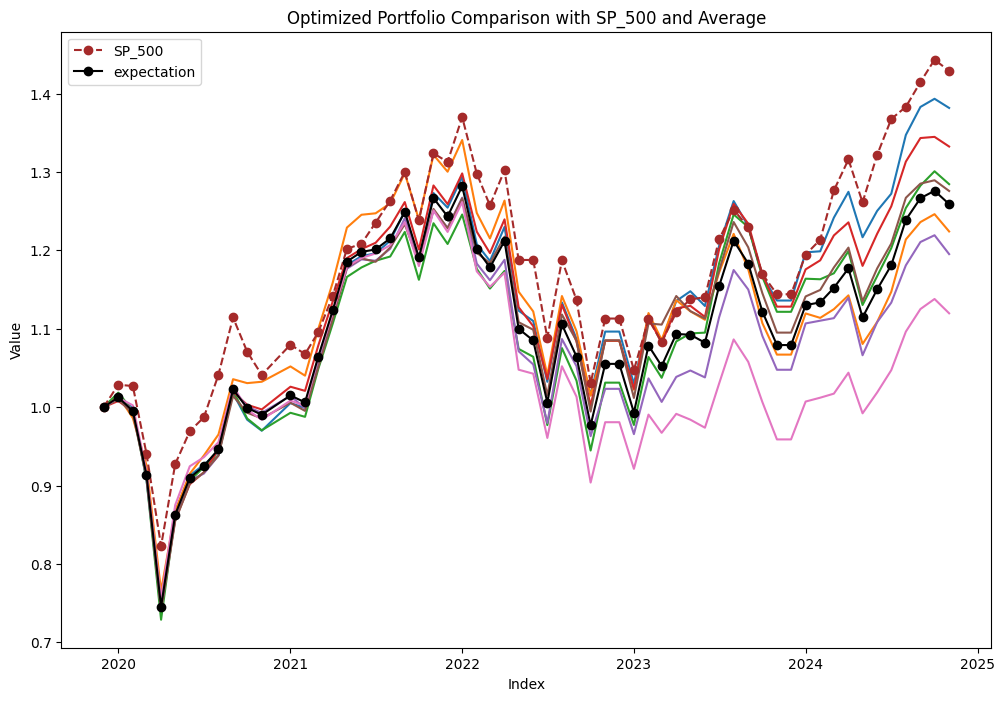

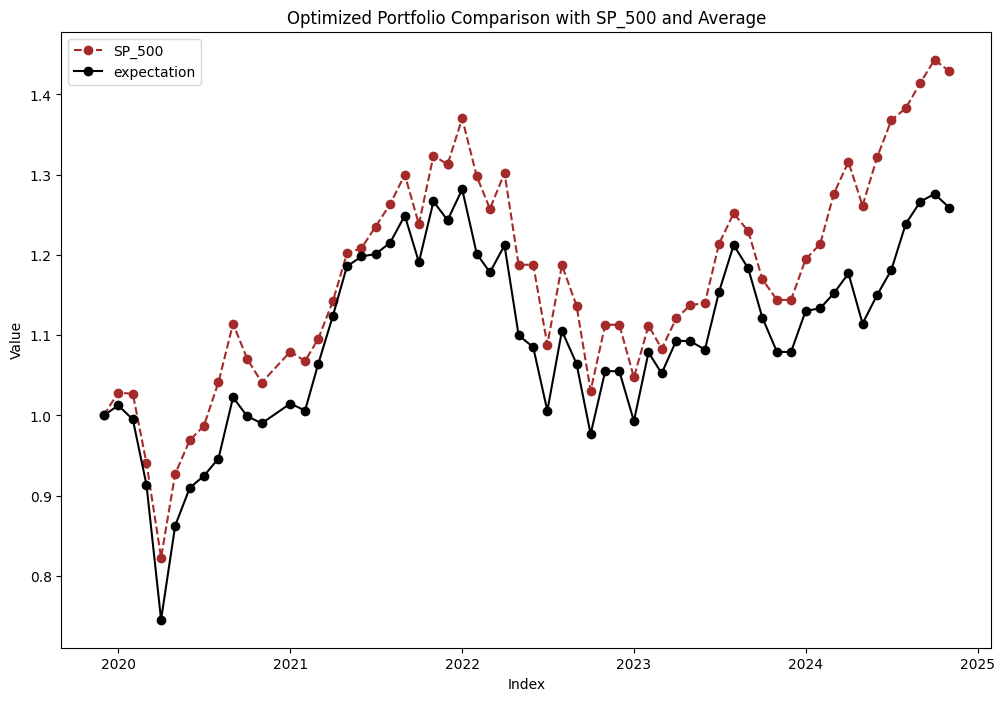

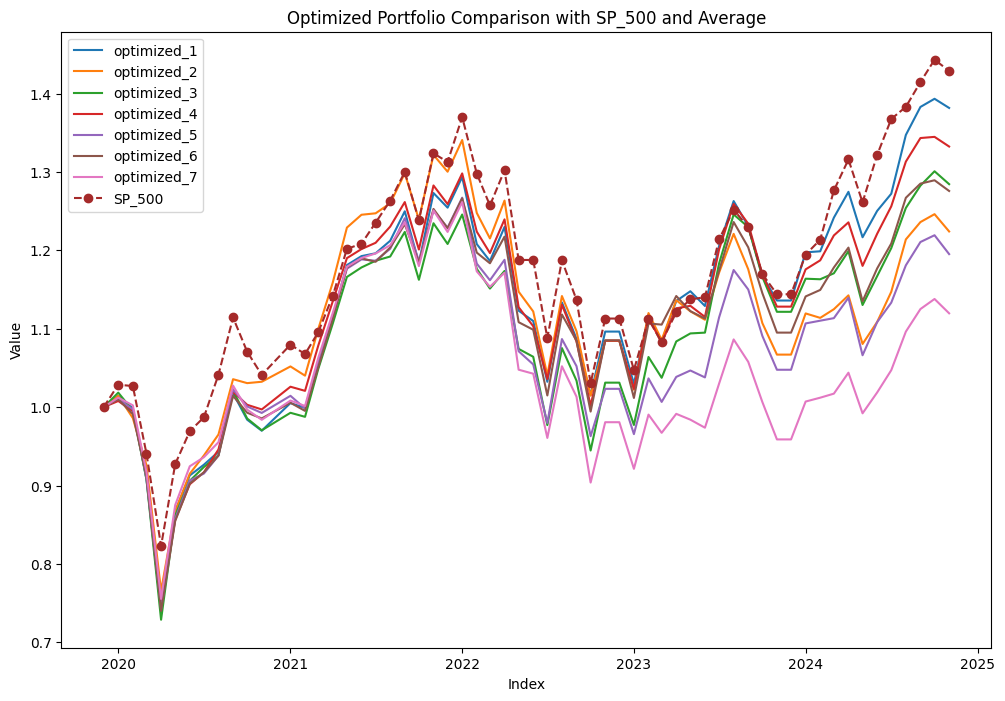

,SP_500,Optimized Portfolio
Date,,
2019-12-01,1.000000,1.000000
2020-01-01,1.028590,1.012532
2020-02-01,1.026915,0.995049
2020-03-01,0.940542,0.913522
2020-04-01,0.822862,0.745520
2020-05-01,0.927237,0.862759
2020-06-01,0.969224,0.909822
2020-07-01,0.987046,0.924759
2020-08-01,1.041434,0.946356


In [90]:
# TAX LOSS HARVESTING
avg_100=final_visual()#100
final_visual2()
final_visual1()
avg_100

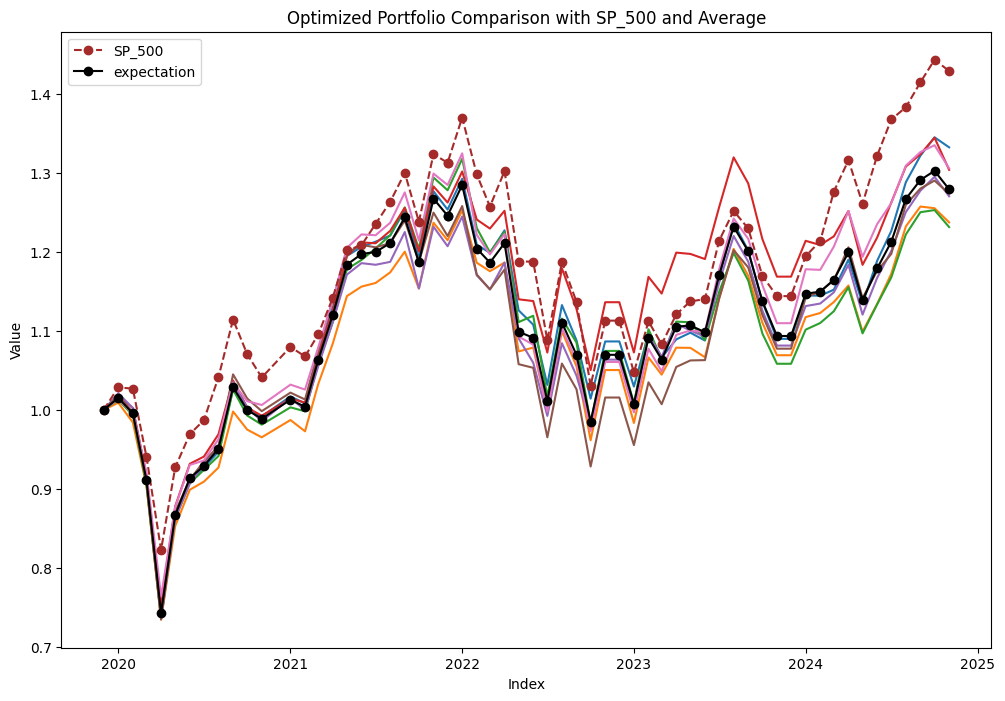

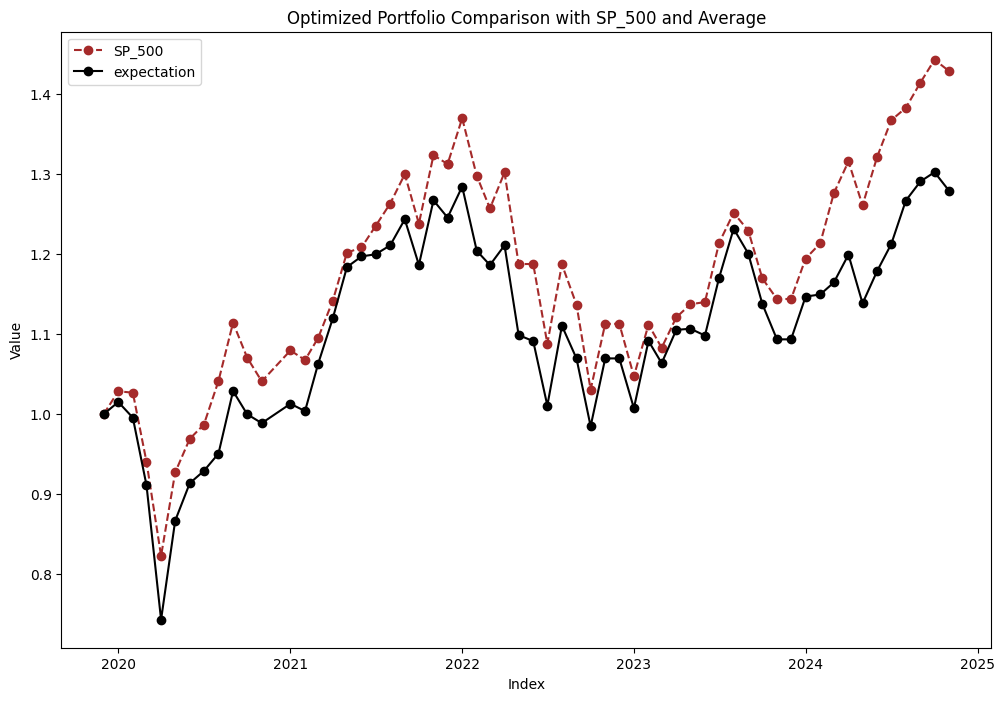

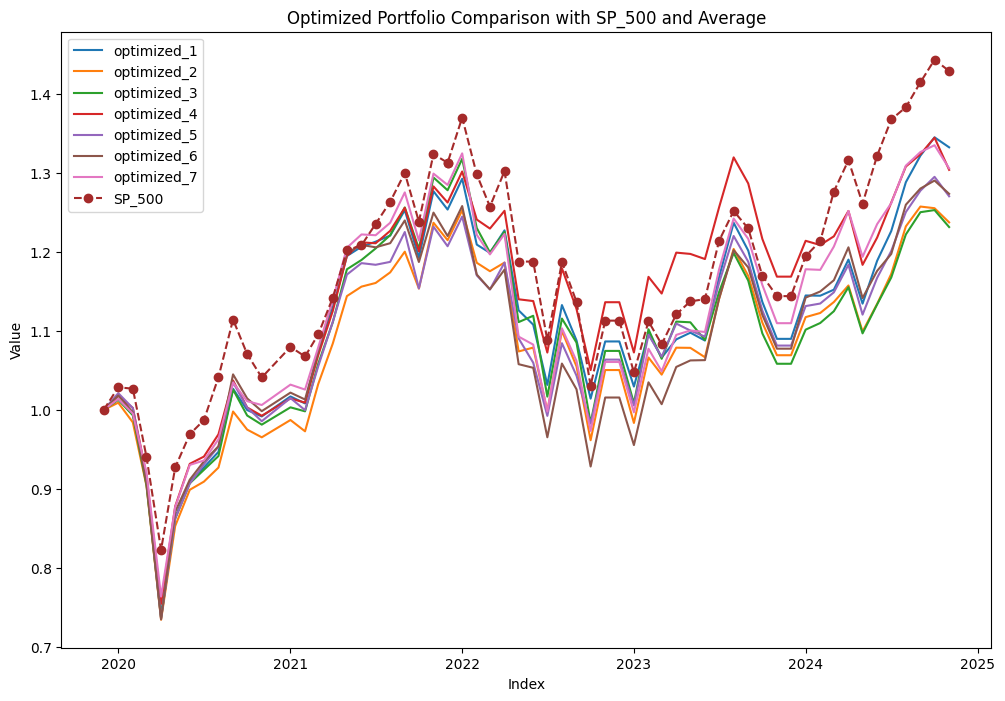

,SP_500,Optimized Portfolio
Date,,
2019-12-01,1.000000,1.000000
2020-01-01,1.028590,1.015233
2020-02-01,1.026915,0.995637
2020-03-01,0.940542,0.911232
2020-04-01,0.822862,0.742971
2020-05-01,0.927237,0.866850
2020-06-01,0.969224,0.913712
2020-07-01,0.987046,0.929055
2020-08-01,1.041434,0.950738


In [92]:
avg_100=final_visual()#100
final_visual2()
final_visual1()
avg_100

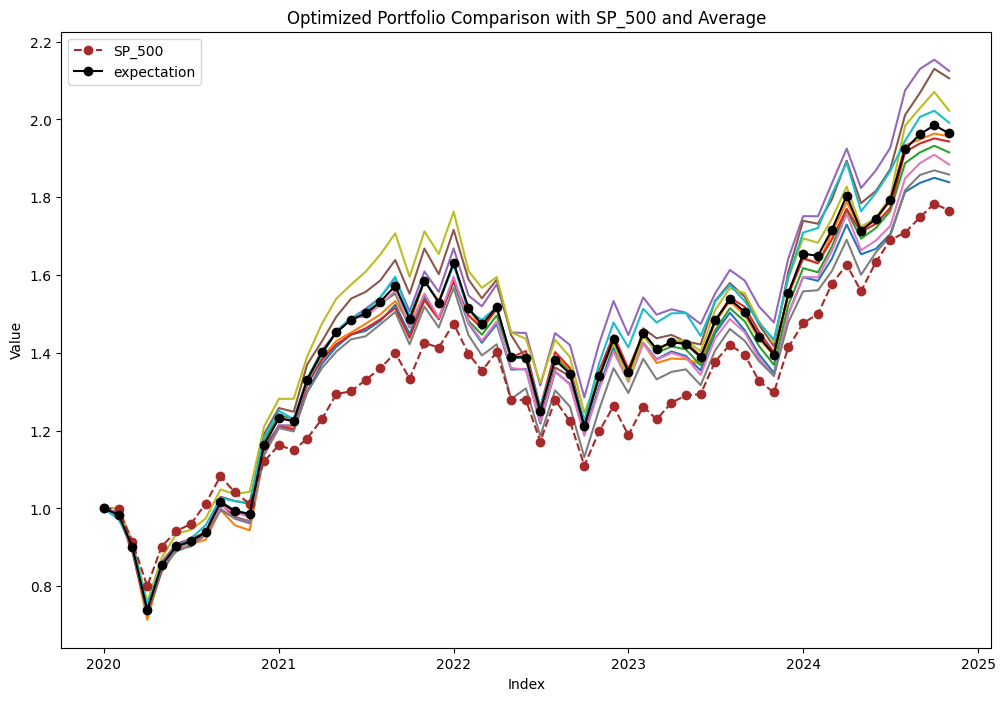

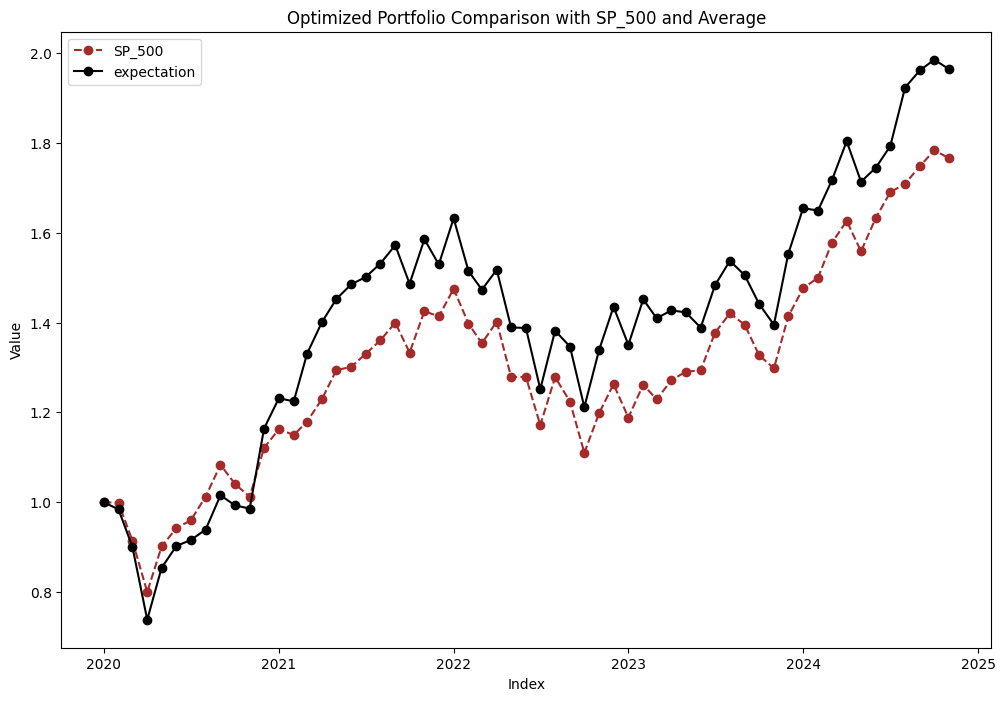

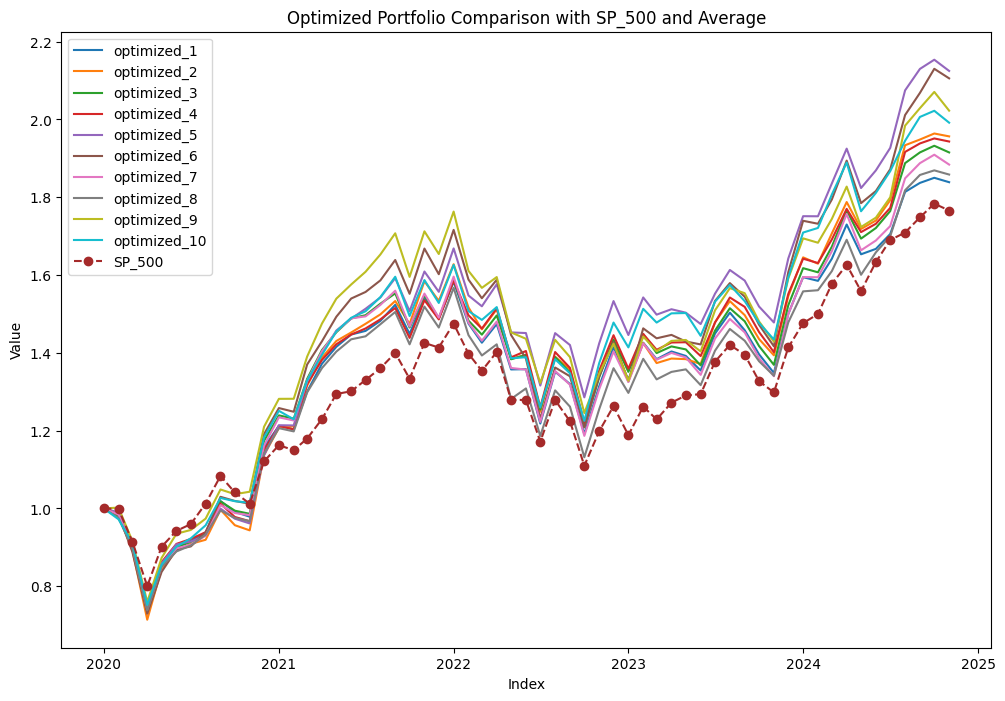

,SP_500,Optimized Portfolio
Date,,
2020-01-01,1.000000,1.000000
2020-02-01,0.998372,0.984004
2020-03-01,0.914399,0.900738
2020-04-01,0.799990,0.738257
2020-05-01,0.901464,0.853845
2020-06-01,0.942284,0.902681
2020-07-01,0.959611,0.915634
2020-08-01,1.012487,0.938991
2020-09-01,1.083426,1.015406


In [75]:
avg_100=final_visual()#100
final_visual2()
final_visual1()
avg_100

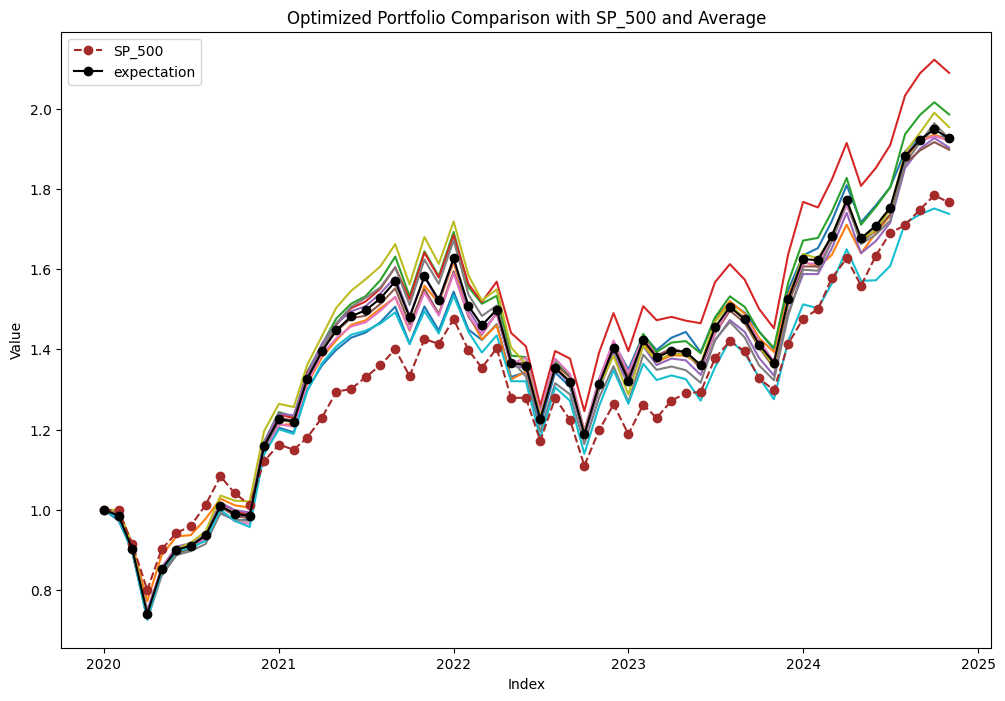

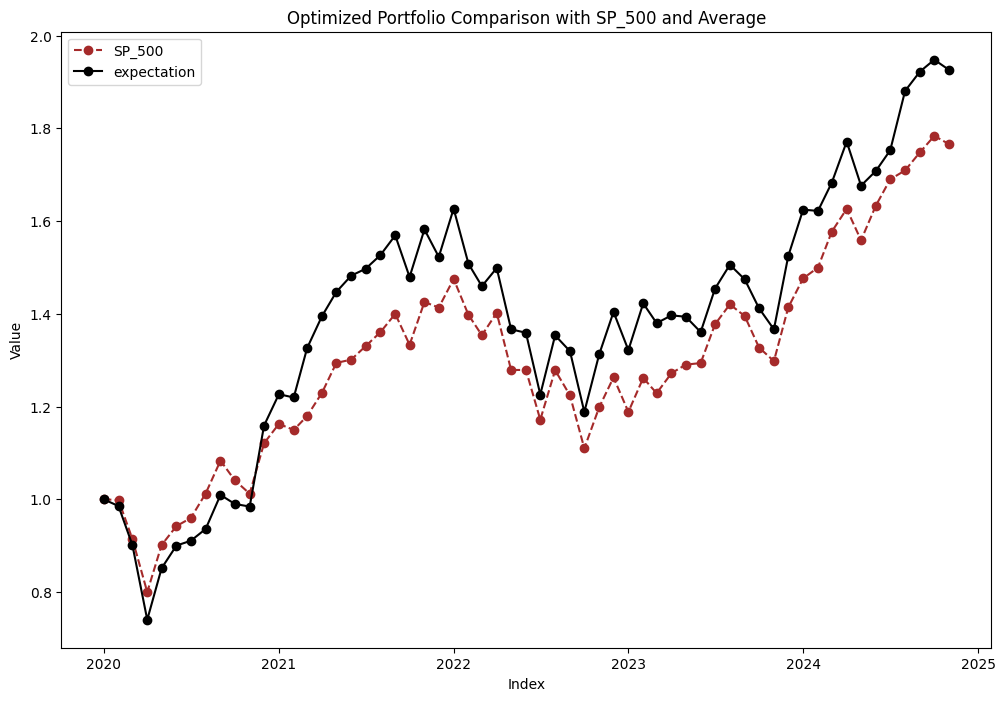

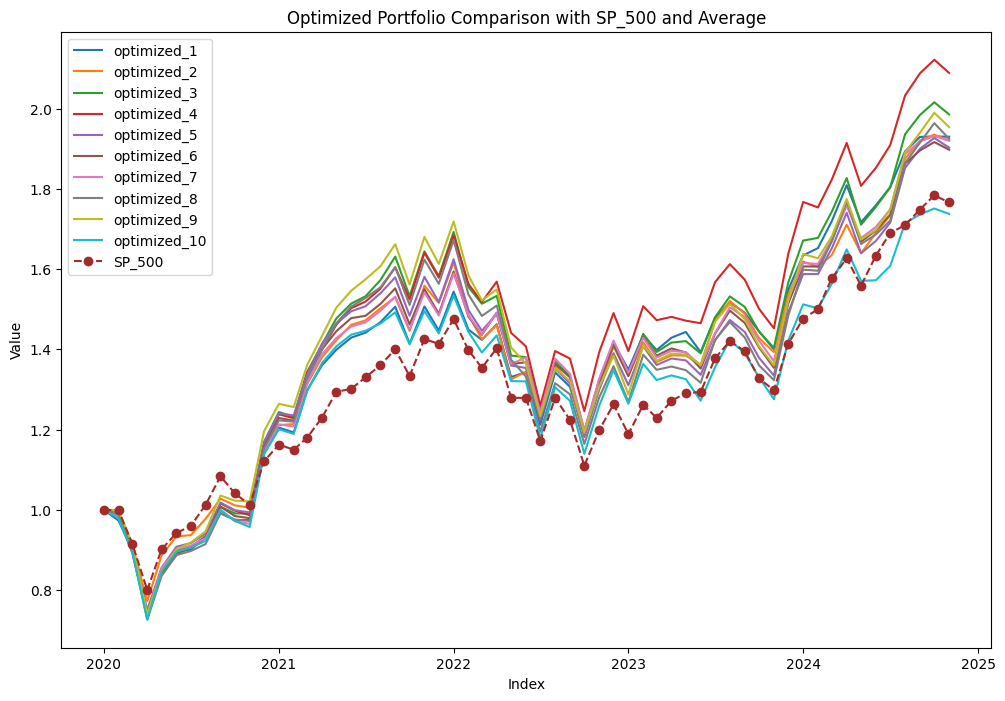

,SP_500,Optimized Portfolio
Date,,
2020-01-01,1.000000,1.000000
2020-02-01,0.998372,0.985512
2020-03-01,0.914399,0.901438
2020-04-01,0.799990,0.740345
2020-05-01,0.901464,0.851407
2020-06-01,0.942284,0.900309
2020-07-01,0.959611,0.910602
2020-08-01,1.012487,0.936050
2020-09-01,1.083426,1.009433


In [72]:
avg_100=final_visual()#100
final_visual2()
final_visual1()
avg_100

In [187]:
flist={}
cumulative_exp_return,yoy_exp_return,sim_one_percentile=cumulative_returns_cal(oos1_list)
sharpe_simulation,sharpe_list_sim,sharpe_spy=list_sharpe_ratio(oos1_list)
print(f'The sharpe ratio of the portfolio on average:{sharpe_simulation}')
print(f'The sharpe ratio of the sp500 : {sharpe_spy}')
print(cumulative_exp_return)
print(sim_one_percentile)
save_df_with_combination_to_excel(sim_one_percentile,'combination_data.xlsx','downside_protection',[1,0,0],2,0,0)
flist['100 rebalance']=avg_100
yoy_exp_return

KeyError: Timestamp('2020-12-01 00:00:00')

In [ ]:
sharpe_simulation,sharpe_list_sim,sharpe_spy=list_sharpe_ratio(oos1_list)
print(f'The sharpe ratio of the portfolio on average:{sharpe_simulation}')
print(f'The sharpe ratio of the sp500 : {sharpe_spy}')

In [188]:
oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation(22,1,0,0,'no')



Column 'FOX' could not be converted to float.
Column 'FOXA' could not be converted to float.
True
Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/78a35025b5a24bd7b882340136a96975-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/78a35025b5a24bd7b882340136a96975-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 2311 COLUMNS
At line 41668 RHS
At line 43975 BOUNDS
At line 44422 ENDATA
Problem MODEL has 2306 rows, 2266 columns and 38428 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 0 - 0.05 seconds
Cgl0004I processed model has 966 rows, 1371 columns (445 integer (445 of which binary)) and 35672 elements
Cbc0038I Initial

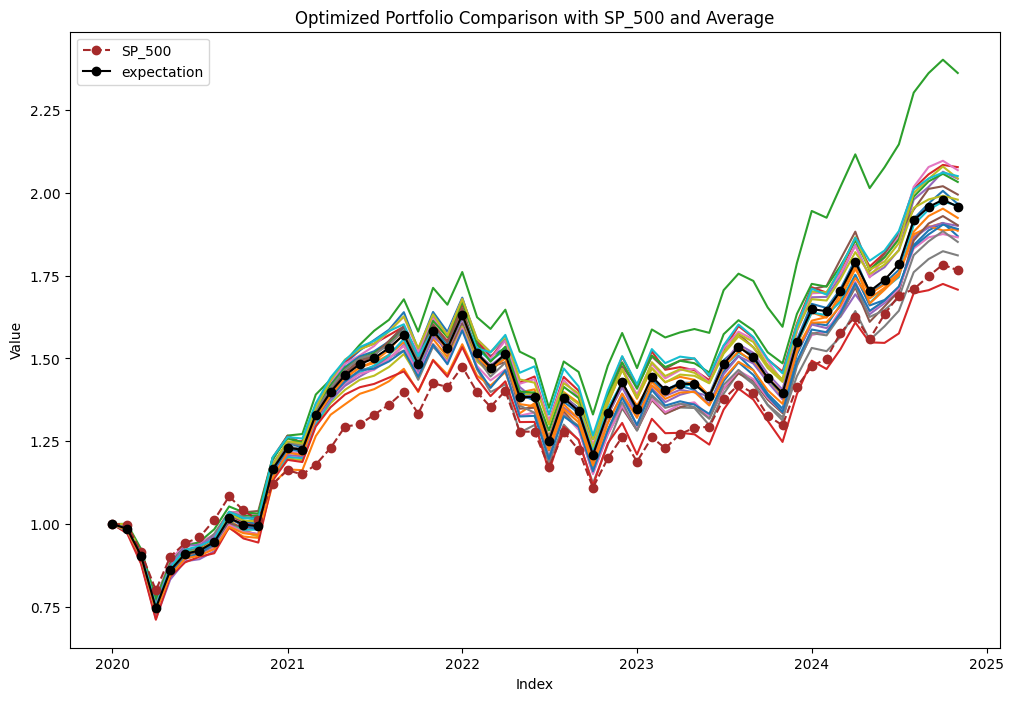

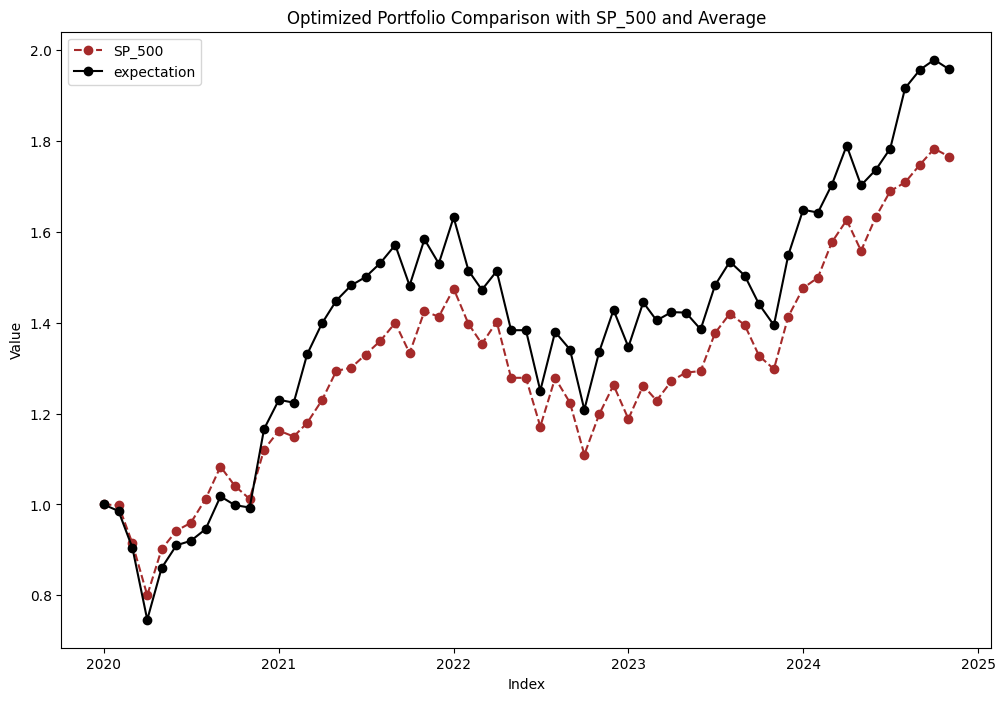

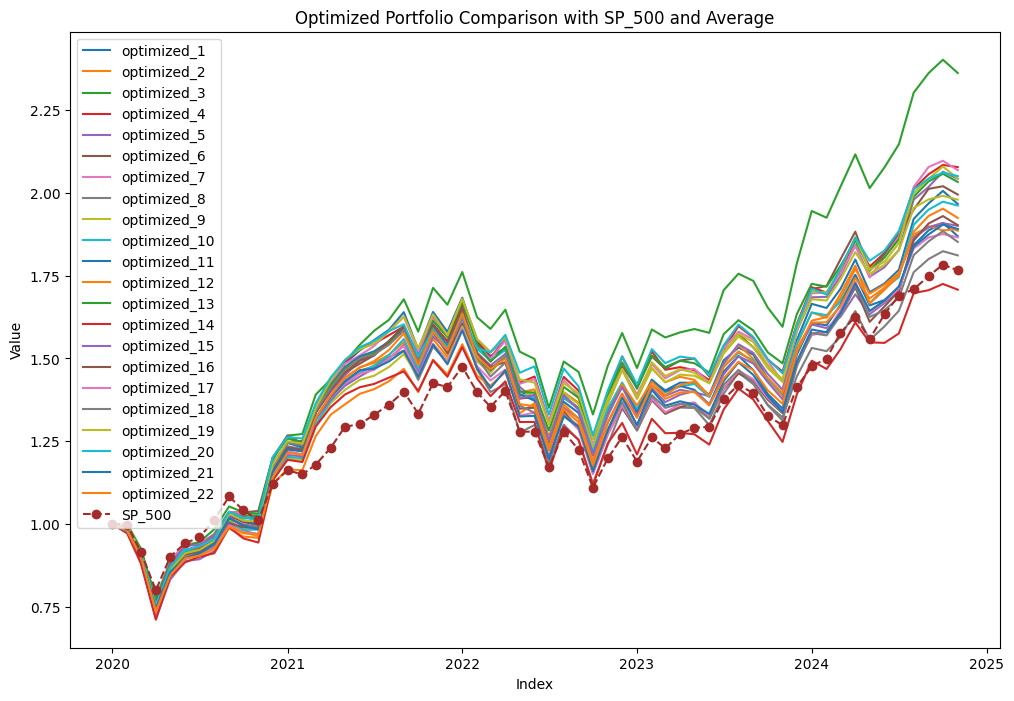

,SP_500,Optimized Portfolio
Date,,
2020-01-01,1.000000,1.000000
2020-02-01,0.998372,0.985658
2020-03-01,0.914399,0.904639
2020-04-01,0.799990,0.746263
2020-05-01,0.901464,0.860109
2020-06-01,0.942284,0.910232
2020-07-01,0.959611,0.919960
2020-08-01,1.012487,0.945848
2020-09-01,1.083426,1.017801


conds)
Cbc0010I After 221000 nodes, 12200 on tree, 0.016092726 best solution, best possible 0 (56788.98 seconds)
Cbc0010I After 222000 nodes, 12376 on tree, 0.016092726 best solution, best possible 0 (57160.59 seconds)
Cbc0010I After 223000 nodes, 12456 on tree, 0.016092726 best solution, best possible 0 (57913.58 seconds)
Cbc0010I After 224000 nodes, 12520 on tree, 0.016092726 best solution, best possible 0 (58831.67 seconds)
Cbc0010I After 225000 nodes, 12524 on tree, 0.016092726 best solution, best possible 0 (60194.84 seconds)
Cbc0010I After 226000 nodes, 12586 on tree, 0.016092726 best solution, best possible 0 (61411.45 seconds)
Cbc0010I After 227000 nodes, 12700 on tree, 0.016092726 best solution, best possible 0 (61771.49 seconds)
Cbc0010I After 228000 nodes, 12740 on tree, 0.016092726 best solution, best possible 0 (61901.44 seconds)
Cbc0010I After 229000 nodes, 12766 on tree, 0.016092726 best solution, best possible 0 (62103.51 seconds)
Cbc0010I After 230000 nodes, 12862 on t

In [189]:
avg_100=final_visual()#100
final_visual2()
final_visual1()
avg_100


In [192]:

cumulative_exp_return,yoy_exp_return,sim_one_percentile=cumulative_returns_cal(oos1_list)
sharpe_simulation,sharpe_list_sim,sharpe_spy=list_sharpe_ratio(oos1_list)
print(f'The sharpe ratio of the portfolio on average:{sharpe_simulation}')
print(f'The sharpe ratio of the sp500 : {sharpe_spy}')
print(cumulative_exp_return)
print(sim_one_percentile)
save_df_with_combination_to_excel(sim_one_percentile,'combination_data.xlsx','downside_protection',[1,0,0],11,0,0)
flist['100']=avg_100
yoy_exp_return

The sharpe ratio of the portfolio on average:0    0.62092
dtype: float64
The sharpe ratio of the sp500 : 0.5962031559179566
Year                2021       2022       2023       2024
Percentile                                               
99 percentile  26.717420  76.104624  47.090267  94.542316
Average        23.053826  63.232326  34.682695  64.897202
1 percentile   19.386646  53.410509  21.004755  49.332261
sp500          16.258962  47.524096  18.841064  47.636981
      1 percentile return in %
Year                          
1                        17.10
2                        27.20
3                       -22.75
4                        18.51
5                        14.51


,1,2,3,4,5
99th Percentile,26.71,38.79,-11.98,31.78,21.81
Median,23.29,33.02,-17.90,21.98,18.69
1st Percentile,17.10,27.20,-22.75,18.51,14.51
SP500,16.26,26.89,-19.44,24.23,19.62


In [193]:
sharpe_simulation,sharpe_list_sim,sharpe_spy=list_sharpe_ratio(oos1_list)
print(f'The sharpe ratio of the portfolio on average:{sharpe_simulation}')
print(f'The sharpe ratio of the sp500 : {sharpe_spy}')


The sharpe ratio of the portfolio on average:0    0.62092
dtype: float64
The sharpe ratio of the sp500 : 0.5962031559179566


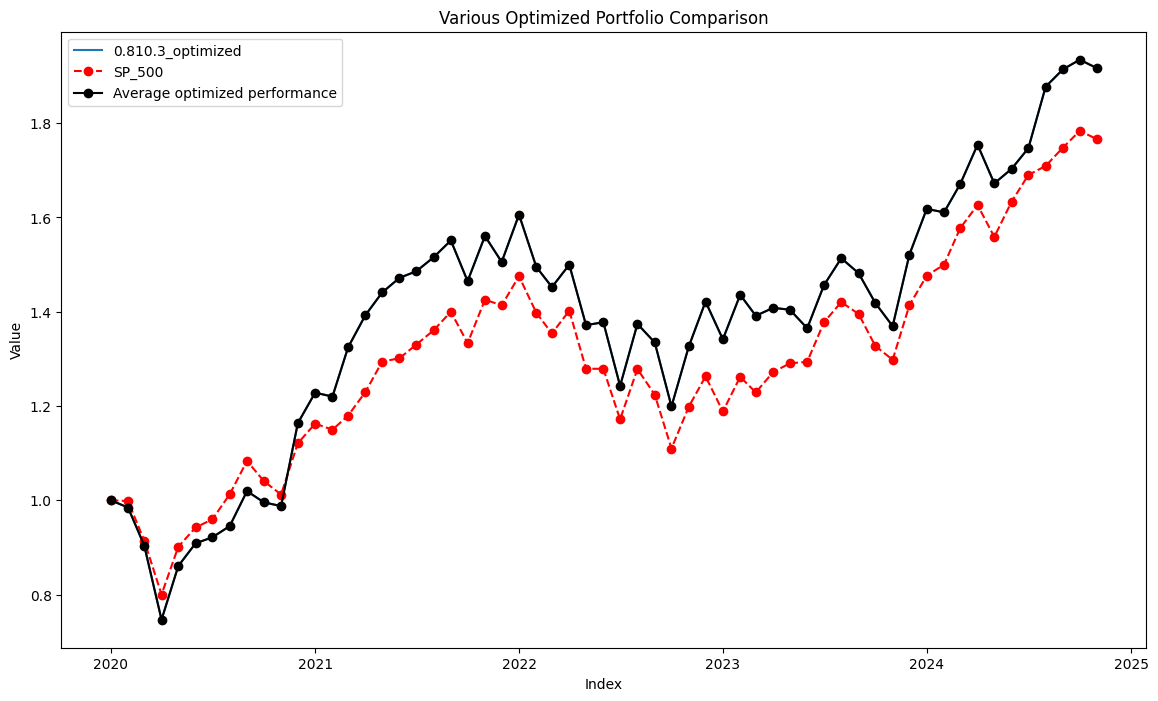

In [90]:
finale_visual(flist)

# Saving analysis to excel sheet

In [ ]:
from openpyxl import Workbook
workbook_filename = 'combination_data.xlsx'
wb = Workbook()
wb.save(workbook_filename)


In [ ]:
save_df_with_combination_to_excel(sim_one_percentile,workbook_filename,'downside_protection',[1,0.75,0.5],0,0,0)

(1,)

In [ ]:
save_df_with_combination_to_excel(gdsk,workbook_filename,'downside_protection',['SP500','SP500','SP500'],1,0,0)

(2,)

In [ ]:
save_df_with_combination_to_excel(sim_one_percentile,workbook_filename,'downside_protection',[1,0.5,0.5],2,0,0)

(3,)

# Error checking area

In [ ]:
simulator(1,0,0,n_year_before,out_of_sample_year_end[2],upatebudget,50)
sjijas=out_of_sampless(out_of_sample_year_start[3],out_of_sample_year_end[3])
tostorelist.append(sjijas)
upatebudget=sjijas['Optimized Portfolio'][-1]*1000000




Column 'FOX' could not be converted to float.
Column 'FOXA' could not be converted to float.
Column 'TPL' could not be converted to float.
True


KeyboardInterrupt: 

In [ ]:
upatebudget=sjijas['Optimized Portfolio'][-1]*1000000

In [ ]:
simulator(1,0,0,n_year_before,n_year_after,1000000,50)
sjijas=out_of_sampless(out_of_sample_year_start[1],out_of_sample_year_end[1])
tostorelist.append(sjijas)
upatebudget=sjijas['Optimized Portfolio'][-1]*1000000




Column 'FOX' could not be converted to float.
Column 'FOXA' could not be converted to float.
True
Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/d158aa235171444682b203a5a0404b18-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/d158aa235171444682b203a5a0404b18-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 2316 COLUMNS
At line 41761 RHS
At line 44073 BOUNDS
At line 44521 ENDATA
Problem MODEL has 2311 rows, 2271 columns and 38514 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 0 - 0.07 seconds
Cgl0004I processed model has 968 rows, 1374 columns (446 integer (446 of which binary)) and 35752 elements
Cbc0038I Initial

In [ ]:
upatebudget

1272053.7273467889

In [ ]:
out_of_sample_year_end[2]

'2021-12-01'

In [59]:
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS

def estimate_rolling_ff3_betas(stock_weights, factors, window): #stock_weightshts is opt_portf_weights appended or not, factros is ff3 monthly, window is number of months used in regression analysis
    # creates roll_betas df with equal allignment 
    stocks = stock_weights.columns
    factors_list = ['Intercept', 'Mkt-RF', 'SMB', 'HML']
    multi_cols = pd.MultiIndex.from_product([stocks, factors_list], names=['Stock', 'Factor'])
    rolling_betas = pd.DataFrame(index=stock_weights.index, columns=multi_cols, dtype=float)
    
    # runs rolling regression for ff3 betas
    for stock in stocks:
        # y variable: stock excess returns
        y = stock_weights[stock] - factors['RF'] 
        # X variables: Mkt-RF, SMB, HML (plus intercept)
        X = sm.add_constant(factors[['Mkt-RF', 'SMB', 'HML']], has_constant='add')  
        rolling_model = RollingOLS(y, X, window=window)
        rolling_result = rolling_model.fit()

        # const get converted to intercept
        rolling_params = rolling_result.params.rename(columns={'const': 'Intercept'}) # intercept is the same as RF in port_betas fnct

        # indexes to match rolling_betas index
        rolling_params = rolling_params.reindex(rolling_betas.index)

        # Assigns each factor's rolling betas to rolling_betas df to use for different timeframes
        for factor in factors_list:
            if factor in rolling_params.columns: 
                rolling_betas.loc[:, (stock, factor)] = rolling_params[factor].to_numpy()
    rolling_betas = rolling_betas*100
    return rolling_betas
# For refrence, the intercept (alpha) in this case is a constant for the regression models, it is effecitvely the 
# the excess return for a risk free rate.

In [60]:
def optimal_weights_appended(opt_port):
    tickers_opt = opt_port.index.tolist()
    prices = yf.download(tickers_opt, start=oos1_new_performance.index[0],end=oos1_new_performance.index[-1],interval="1mo")['Adj Close']
    
    # if value is NA, averages it with the before and after, as it would be too difficult to manually enter it if we scale up the use of this
    prices = prices.interpolate(method = 'linear', limit_direction = 'both') 
    base_prices = prices.iloc[0]
    holding_values = pd.DataFrame(index=prices.index, columns=prices.columns)
    for tickers_opt in prices.columns:
        weight_opt = opt_port.loc[tickers_opt].iloc[0]
        # (price / price_base) * initial_weight.
        holding_values[tickers_opt] = (prices[tickers_opt] / base_prices[tickers_opt]) * weight_opt

    # calc total portfolio value for each month.
    portfolio_value = holding_values.sum(axis=1)
    
    # normalize the values
    opt_portfolio_weights_appended = holding_values.div(portfolio_value, axis=0)
    return opt_portfolio_weights_appended

In [61]:
def get_portfolio_betas_for_date(date, opt_portfolio_weights_appended, i):
    if isinstance(date, str):
        date = datetime.strptime(date, "%Y-%m-%d")
    if date > oos1_new_performance.index[5]:
        opt_portfolio_weights_appended = optimal_weights_appended(opt_portfolio_weights_appended)
        weights_opt = opt_portfolio_weights_appended.loc[date]
        rolling_betas = estimate_rolling_ff3_betas(opt_portfolio_weights_appended, ff3_monthly, i) 
        # grab the single row for the given date
        row = rolling_betas.loc[date]  
        factor_level = rolling_betas.columns.levels[1]
        
        # build a dict of factor exposures
        portfolio_factor_exposures = {}
        
        for factor in factor_level:
            # weighted sum of each ticker's factor betas
            total_factor_beta = 0.0
            for ticker, w in weights_opt.items():
                beta_value = row[(ticker, factor)]
                total_factor_beta += w * beta_value
    
            portfolio_factor_exposures[factor] = total_factor_beta
        final_df_betas = pd.Series(portfolio_factor_exposures, name=date)
        return pd.concat([final_df_betas.iloc[2:], final_df_betas.iloc[:2]]).iloc[:-1] # reindexes to match the usual order and drops intercept row
    else:
        print("Error, needs 6 months to run rolling window analysis")

In [62]:
def monthly_beta_change(i, futures_df):
    # so you input the index you start at first (i) and it returns a data frame of each the difference of each 3 factors for the next month 
    # this approach makes it so you can add the options to be considered into the ff3 differnces to compare and use w/o figures
    
    opt_portf_index = opt_portf_weights #opt_portfolio_weights.loc[oos1_new_performance.index[i]]# I was incorrectly using opt_portf_weights for months that arent the first month, so instead I can pull that month from the M/M weights. 
    
    ff3_df_start = get_portfolio_betas_for_date(oos1_new_performance.index[i], opt_portf_index, i)
    opt_portf_weights_appended = pd.concat([opt_portf_index, futures_df])
    if futures_df.empty:
        opt_portf_weights_appended = opt_portf_index.copy()
    else:
        opt_portf_weights_appended = pd.concat([opt_portf_index, futures_df])
        opt_portf_weights_appended["New Weights"] = opt_portf_weights_appended["New Weights"] / opt_portf_weights_appended["New Weights"].abs().sum()
    ff3_df_end = get_portfolio_betas_for_date(oos1_new_performance.index[i+1], opt_portf_weights_appended, i+1)   

    return ff3_df_end, ff3_df_start # i dont know if ff3_df_start has any benefit?

In [63]:
def get_fama_by_q():
    ff3_quarters = gff.famaFrench3Factor(frequency='m')
    ff3_quarters.rename(columns={"date_ff_factors": 'Date'}, inplace=True)
    ff3_quarters['Date'] = pd.to_datetime(ff3_quarters['Date'])
    ff3_quarters.set_index('Date', inplace=True)
    ff3_quarters.sort_index(inplace=True)
    ff3_quarterly = ff3_quarters.resample('Q').mean()

    # Resample the quarterly data to monthly frequency by forward-filling
    return ff3_quarters.loc[oos1_new_performance.index]

# Ill keep this incase we want to hedge by quarters, as this works as a base case for ff3 regression


In [64]:
def get_dynamic_multiplier(futures_prices, future_ticker, desired_notional_exposure):
    current_price = futures_prices.loc[future_ticker]
    multiplier = desired_notional_exposure / current_price
    return abs(multiplier.item())

In [65]:
# similar to hedge_portoflio_function, jsut written for all 3 factros and specific indexes
def calculate_futures_positions(current_betas, optimal_betas, portfolio_value, futures_prices, EOM_futures_prices, default_contract_multipliers, desired_notional_exposures, dynamic_tickers, i):
    
    # compute beta differences for each factor:
    delta_MKT = (optimal_betas['Mkt-RF'] - current_betas['Mkt-RF'])
    delta_SMB = (optimal_betas['SMB'] - current_betas['SMB'])
    delta_HML = (optimal_betas['HML'] - current_betas['HML'])
    
    positions = []
    scale_factor = 10 # this is an aproach- not perfect (somewhat of a short term fix), if I rework exposure it may noy be neccessary  
    def get_multiplier(ticker):
        # checks if index is held constant or not
        if ticker in dynamic_tickers:
            return get_dynamic_multiplier(futures_prices, ticker, desired_notional_exposures[ticker])
        else:
            return default_contract_multipliers[ticker] 

    # Market factor: ES=F
    pos_MKT = "LONG" if delta_MKT > 0 else ("SHORT" if delta_MKT < 0 else "NO ACTION")
    mult_MKT = get_multiplier("ES=F")
    contracts_MKT = (abs(delta_MKT * portfolio_value) / (futures_prices.loc["ES=F"] * mult_MKT)
                     if mult_MKT > 0 else 0)
    if round(contracts_MKT.item(),0) == 0:
        pos_MKT = "NO ACTION"
        
    positions.append({
        "ETF Name": "ES=F",
        "Position": pos_MKT,
        "Number of Contracts": round(contracts_MKT, 0).item(),
        "Cost of Contracts ($)": round(futures_prices.loc["ES=F"]*mult_MKT *round(contracts_MKT, 0),2).item()/scale_factor,
        "EOM Value ($)": round(EOM_futures_prices.loc["ES=F"]*mult_MKT *round(contracts_MKT, 0),2).item()/scale_factor,
        "Multiplier": round(mult_MKT,2)
    })
    
    # SMB factor:
    # IWM (small-cap) follows the sign of delta_SMB.
    pos_IWM = "LONG" if delta_SMB > 0 else ("SHORT" if delta_SMB < 0 else "NO ACTION")
    mult_IWM = get_multiplier("IWM")
    contracts_IWM = (abs(delta_SMB * portfolio_value) / (futures_prices.loc["IWM"] * mult_IWM)
                     if mult_IWM > 0 else 0)
    if round(contracts_IWM.item(),0) == 0:
        pos_IWM = "NO ACTION"
        
    positions.append({
        "ETF Name": "IWM",
        "Position": pos_IWM,
        "Number of Contracts": round(contracts_IWM, 0).item(),
        "Cost of Contracts ($)": round(futures_prices.loc["IWM"]*mult_IWM *round(contracts_IWM, 0),2).item()/scale_factor,
        "EOM Value ($)": round(EOM_futures_prices.loc["IWM"]*mult_IWM *round(contracts_IWM, 0),2).item()/scale_factor,
        "Multiplier": mult_IWM
    })
    
    # IWB (large-cap) takes the opposite signal of delta_SMB.
    pos_IWB = "SHORT" if delta_SMB > 0 else ("LONG" if delta_SMB < 0 else "NO ACTION")
    mult_IWB = get_multiplier("IWB")
    contracts_IWB = (abs(delta_SMB * portfolio_value) / (futures_prices.loc["IWB"] * mult_IWB)
                     if mult_IWB > 0 else 0)
    if round(contracts_IWB.item(),0) == 0:
        pos_IWB = "NO ACTION"
        
    positions.append({
        "ETF Name": "IWB",
        "Position": pos_IWB,
        "Number of Contracts": round(contracts_IWB, 0).item(),
        "Cost of Contracts ($)": round(futures_prices.loc["IWB"]*mult_IWB *round(contracts_IWB, 0),2).item()/scale_factor,
        "EOM Value ($)": round(EOM_futures_prices.loc["IWB"]*mult_IWB *round(contracts_IWB, 0),2).item()/scale_factor,
        "Multiplier": mult_IWB
    })
    
    # HML factor:
    # IWD (value) follows the sign of delta_HML.
    pos_IWD = "LONG" if delta_HML > 0 else ("SHORT" if delta_HML < 0 else "NO ACTION")
    mult_IWD = get_multiplier("IWD")
    contracts_IWD = (abs(delta_HML * portfolio_value) / (futures_prices.loc["IWD"] * mult_IWD)
                     if mult_IWD > 0 else 0)
    if round(contracts_IWD.item(),0) == 0:
        pos_IWD = "NO ACTION"
        
    positions.append({
        "ETF Name": "IWD",
        "Position": pos_IWD,
        "Number of Contracts": round(contracts_IWD, 0).item(),
        "Cost of Contracts ($)": round(futures_prices.loc["IWD"]*mult_IWD *round(contracts_IWD, 0), 2).item()/scale_factor,
        "EOM Value ($)": round(EOM_futures_prices.loc["IWD"]*mult_IWD *round(contracts_IWD, 0), 2).item()/scale_factor,
        "Multiplier": mult_IWD
         })
    
    # IWF (growth) takes the opposite signal of delta_HML.
    pos_IWF = "SHORT" if delta_HML > 0 else ("LONG" if delta_HML < 0 else "NO ACTION")
    mult_IWF = get_multiplier("IWF")
    contracts_IWF = (abs(delta_HML * portfolio_value) / (futures_prices.loc["IWF"] * mult_IWF)
                     if mult_IWF > 0 else 0)
    if round(contracts_IWF.item(),0) == 0:
        pos_IWF = "NO ACTION"
        
    positions.append({
        "ETF Name": "IWF",
        "Position": pos_IWF,
        "Number of Contracts": round(contracts_IWF, 0).item(),
        "Cost of Contracts ($)": round(futures_prices.loc["IWF"]*mult_IWF *round(contracts_IWF, 0), 2).item()/scale_factor,
        "EOM Value ($)": round(EOM_futures_prices.loc["IWF"]*mult_IWF *round(contracts_IWF, 0),2).item()/scale_factor,
        "Multiplier": mult_IWF
    })

    return pd.DataFrame(positions, columns=["ETF Name", "Position", "Number of Contracts", "Cost of Contracts ($)", "EOM Value ($)"]) # WILL DELETE THE /10
    

In [66]:
def compute_optimal_exposure(change_in_betas, prices, future_ff3_factors):
    # function plugs the matrix of a solver into the formula B*w = delta (desired change in portfolio's factor exposure)
 
    df_factors = future_ff3_factors.unstack(level='Factor')
    # df_factors now has columns [Intercept, Mkt-RF, SMB, HML], indexed by [ES=F, IWB, IWD, IWF, IWM]

    # drop the 'Intercept' column
    df_factors = df_factors[['Mkt-RF', 'SMB', 'HML']]  # keep only the 3 factors

    df_factors = df_factors.reindex(prices.index)

    #    Rows = factors, columns = 
    factors = ['Mkt-RF', 'SMB', 'HML']
    c_matrix = df_factors[factors].T.values  # shape: (3, 5)

    # we want to refactor it to a difference of 0 between target and current betas, so 0.0 for all 3:
    delta_vec = np.array([
        change_in_betas.get('Mkt-RF', 0.0),
        change_in_betas.get('SMB',    0.0),
        change_in_betas.get('HML',    0.0)
    ])

    #    B * w = delta_vec
    #    w = # of SHARES for each ticker
    w, residuals, rank, s = np.linalg.lstsq(c_matrix, delta_vec, rcond=None)
    prices = prices["Prices"]
    #w = w.flatten()
    
    df_result = pd.DataFrame({
        "Shares": w,
        "Price": prices,
    }, index=df_factors.index)

    # Notional = how many shares * price per share
    df_result["Notional"] = df_result["Shares"] * df_result["Price"]

    return df_result


In [67]:
# need function to calculate p/l of the hedging 
def calc_hedging_pl(hedge_df):

    # computes the change in value, profit if stocks goes up and is LONG, and loss if stock goes up and is SHORT - vice versa 
    hedge_df["P/L ($)"] = hedge_df.apply(
        lambda row: (row["EOM Value ($)"] - row["Cost of Contracts ($)"])
        if row["Position"] == "LONG" else
        (row["Cost of Contracts ($)"] - row["EOM Value ($)"]),
        axis=1
    )

    # computes +- change relative to total value of futures, because the amounts are not constant 
    total_cost = hedge_df["Cost of Contracts ($)"].sum()
    hedge_df["P/L (%)"] = hedge_df.apply(
        lambda row: (row["P/L ($)"] / total_cost * 100)
        if row["Cost of Contracts ($)"] != 0 else 0,
        axis=1
    )

    hedge_df["P/L ($)"] = hedge_df["P/L ($)"].round(2)
    hedge_df["P/L (%)"] = hedge_df["P/L (%)"].round(2)
    
    return hedge_df

In [117]:
future_data = pd.read_csv('daat.csv')
future_data.set_index('TICKER', inplace=True)
future_data=future_data[['date','PRC']]
future_data

,date,PRC
TICKER,,
EWST,2000-01-31,8.12500
EWST,2000-02-29,8.25000
EWST,2000-03-31,-8.00000
EWST,2000-04-28,-8.09375
EWST,2000-05-31,-7.90625
...,...,...
TSLA,2024-08-30,214.11000
TSLA,2024-09-30,261.63000
TSLA,2024-10-31,249.85001


In [ ]:
end1 = oos1_list[0].index[-1]
start1 = oos1_list[0].index[0]

MKT_RF_futures = future_data.loc['SPY']
MKT_RF_futures.set_index('date', inplace=True)

# Pre Process to average NAs with last and next month, contracts do get redownloaded, but this method is used as well-
MKT_RF_futures = MKT_RF_futures.interpolate(method='linear', limit_direction='both')
MKT_RF_futures = MKT_RF_futures.loc[start1:end1]
print(MKT_RF_futures)

TypeError: '<' not supported between instances of 'str' and 'Timestamp'

In [147]:
oos1_list[0]

Ticker,SP_500,Optimized Portfolio
Date,,
2019-12-01,1.000000,1.000000
2020-01-01,1.028590,1.009354
2020-02-01,1.026915,0.995394
2020-03-01,0.940542,0.911128
2020-04-01,0.822862,0.756636
2020-05-01,0.927237,0.863813
2020-06-01,0.969224,0.916221
2020-07-01,0.987046,0.920895
2020-08-01,1.041434,0.942455


Timestamp('2024-11-01 00:00:00')

In [128]:
o1_end_d


'2024-11-29'

In [68]:
# # REWRITE, MKT-RF - SMB - HML, SP_500  & RUSSELL FUTURES TO ACHIEVE OPTIMIZED HEDGING, using monthly futures for now.
from IPython.display import display
famafrenchreturns()

end1 = o1_end_d
start1 = oos1_new_performance.index[0]
#MKT-RF futures
MKT_RF_futures1 = yf.download("ES=F",start=start1,end=end1,interval='1mo')['Adj Close']

# Pre Process to average NAs with last and next month, contracts do get redownloaded, but this method is used as well-
MKT_RF_futures = MKT_RF_futures1.reindex(start1)
MKT_RF_futures = MKT_RF_futures.interpolate(method = 'linear', limit_direction = 'both')

#SMB futures- # this is subject to change
L_R2000F_small_cap = yf.download("IWM",start=start1,end=end1,interval='1mo')['Adj Close']
L_R2000F_small_cap = L_R2000F_small_cap.interpolate(method = 'linear', limit_direction = 'both') 

S_R1000F_large_cap = yf.download("IWB",start=start1,end=end1,interval='1mo')['Adj Close']
S_R1000F_large_cap = S_R1000F_large_cap.interpolate(method = 'linear', limit_direction = 'both') 

s_1 = pd.Series(L_R2000F_small_cap)
s_2 = pd.Series(S_R1000F_large_cap)


#HML futures- # this is subject to change
L_R1000F_value = yf.download("IWD",start=start1,end=end1,interval='1mo')['Adj Close']
L_R1000F_value = L_R1000F_value.interpolate(method = 'linear', limit_direction = 'both') 

S_R1000F_growth = yf.download("IWF",start=start1,end=end1,interval='1mo')['Adj Close']
S_R1000F_growth = S_R1000F_growth.interpolate(method = 'linear', limit_direction = 'both') 

h_1 = pd.Series(L_R1000F_value)
h_2 = pd.Series(S_R1000F_growth)


# combine the 3 dfs to have a total future df
total_futures_df = pd.concat([MKT_RF_futures,s_1, s_2, h_1, h_2], axis= 1).dropna()

#leaving out the minmum variance hedge ratio, but will add it if needed- I wasnt using it in my quarter simulator


#prepares all optimal values from port_betas
#0- MKT, 1- SMB, 2-HML 
betas_target = pd.Series({'Mkt-RF': port_betas.iloc[0][1], 'SMB': port_betas.iloc[1][1], 'HML': port_betas.iloc[2][1]}) # if we want this to change and be dyanimc, we can put in the loop and change M/M

print("Target Beta Values")
display(betas_target)

total_future_pl = 0
#Simulator for 12 months: 
for i in range (6,7):#6-18 for full year):
    
    start_1 = oos1_new_performance.index[i] # must start at the 7th month of trading, as 6 months is needed for regression analysis
    #end1 = 
    betas_current = pd.Series((get_portfolio_betas_for_date(start_1, opt_portf_weights,i)))

    # print("Size of each contract being hedged")
    print("Current Beta Values: ")
    display(pd.DataFrame(betas_current))
    
    print("Difference of Beta Values: ")
    betas_difference = betas_current - betas_target
    display(pd.DataFrame(betas_difference))
    
    future_prices = total_futures_df.iloc[i]
    future_prices = pd.DataFrame({"Prices": [future_prices.iloc[0], future_prices.iloc[1], future_prices.iloc[2],future_prices.iloc[3], future_prices.iloc[4]]}, index=["ES=F", "IWM", "IWB", "IWD", "IWF"])
    EOM_future_prices = total_futures_df.iloc[i+1]
    EOM_future_prices = pd.DataFrame({"Prices": [EOM_future_prices.iloc[0], EOM_future_prices.iloc[1], EOM_future_prices.iloc[2],EOM_future_prices.iloc[3], EOM_future_prices.iloc[4]]}, index=["ES=F", "IWM", "IWB", "IWD", "IWF"])
    # total value of the 5 futures
    F = (future_prices.sum()).item() 

    beta_multiplier = F #B * oos1_new_performance.loc['start1'][1] , maybe?
    nototional_exposure = compute_optimal_exposure(betas_difference*beta_multiplier, future_prices, estimate_rolling_ff3_betas(optimal_weights_appended(future_prices), ff3_monthly, i).iloc[i])
    # need to touch up this function 
    
    #print(nototional_exposure)
    default_contract_multipliers = { "ES=F": 1000, "IWM": 100, "IWB": 100, "IWD": 100, "IWF": 100} # I may try some of these constant 
    dynamic_tickers = {"IWM", "IWB", "IWD", "IWF", "ES=F"} 
    hedge_df = calculate_futures_positions(betas_current, betas_target, B, future_prices, EOM_future_prices, default_contract_multipliers, nototional_exposure.iloc[:,2], dynamic_tickers, i)
    hedge_df = hedge_df.set_index("ETF Name")
    #display(hedge_df)
    hedge_df = calc_hedging_pl(hedge_df)
    display(hedge_df)
    total_future_pl += hedge_df['P/L ($)'].sum()
    
    # Next part is calculating the futures difference on the ff3 betas. The startegy is adding the 5 tickers of futures to opt_portf_weights, with Long contracts being postive and Short negative. 
    # Pre processing/ index matching opt_portf_weights and the future weights 
    
    position_cost_df = hedge_df[["Position", "Cost of Contracts ($)"]].copy()
    position_cost_df["Cost of Contracts ($)"] = position_cost_df.apply(
        lambda row: -row["Cost of Contracts ($)"] if row["Position"] == "SHORT" else row["Cost of Contracts ($)"],
        axis=1
    )
    
    future_weights = position_cost_df.drop(columns=["Position"])
    future_weights["Cost of Contracts ($)"] = future_weights["Cost of Contracts ($)"] /  (B * oos1_new_performance.loc['start_1'][1])
    
    
    future_weights.index = future_weights.index.astype(str)
    future_weights = future_weights.rename(columns={'Cost of Contracts ($)': 'New Weights'})
    future_weights = future_weights.rename_axis("Ticker")

    ff3_df_eom_no_futures = pd.Series((get_portfolio_betas_for_date(oos1_new_performance.index[i+1], opt_portf_weights, i+1)))
    ff3_df_eom_w_futures, ff3_df_start = monthly_beta_change(i, future_weights) 
    print("EOM Fama-French betas WITHOUT futures considered: ")
    display(ff3_df_eom_no_futures)
    print("EOM Fama-French betas WITH futures considered: ")
    display(ff3_df_eom_w_futures)
    print("Difference of betas Fama-French with futures considered vs without futures: ")
    print("\n\n\n")
print(f'Total P/L ($) for all futures: ${total_future_pl:.2f}')


Failed to get ticker 'ES=F' reason: Expecting value: line 1 column 1 (char 0)
[*********************100%%**********************]  1 of 1 completed

1 Failed download:
['ES=F']: Exception('%ticker%: No timezone found, symbol may be delisted')


TypeError: 'Timestamp' object is not iterable